Saved PDF to: C:\Users\lenovo\Downloads\Fig2.pdf


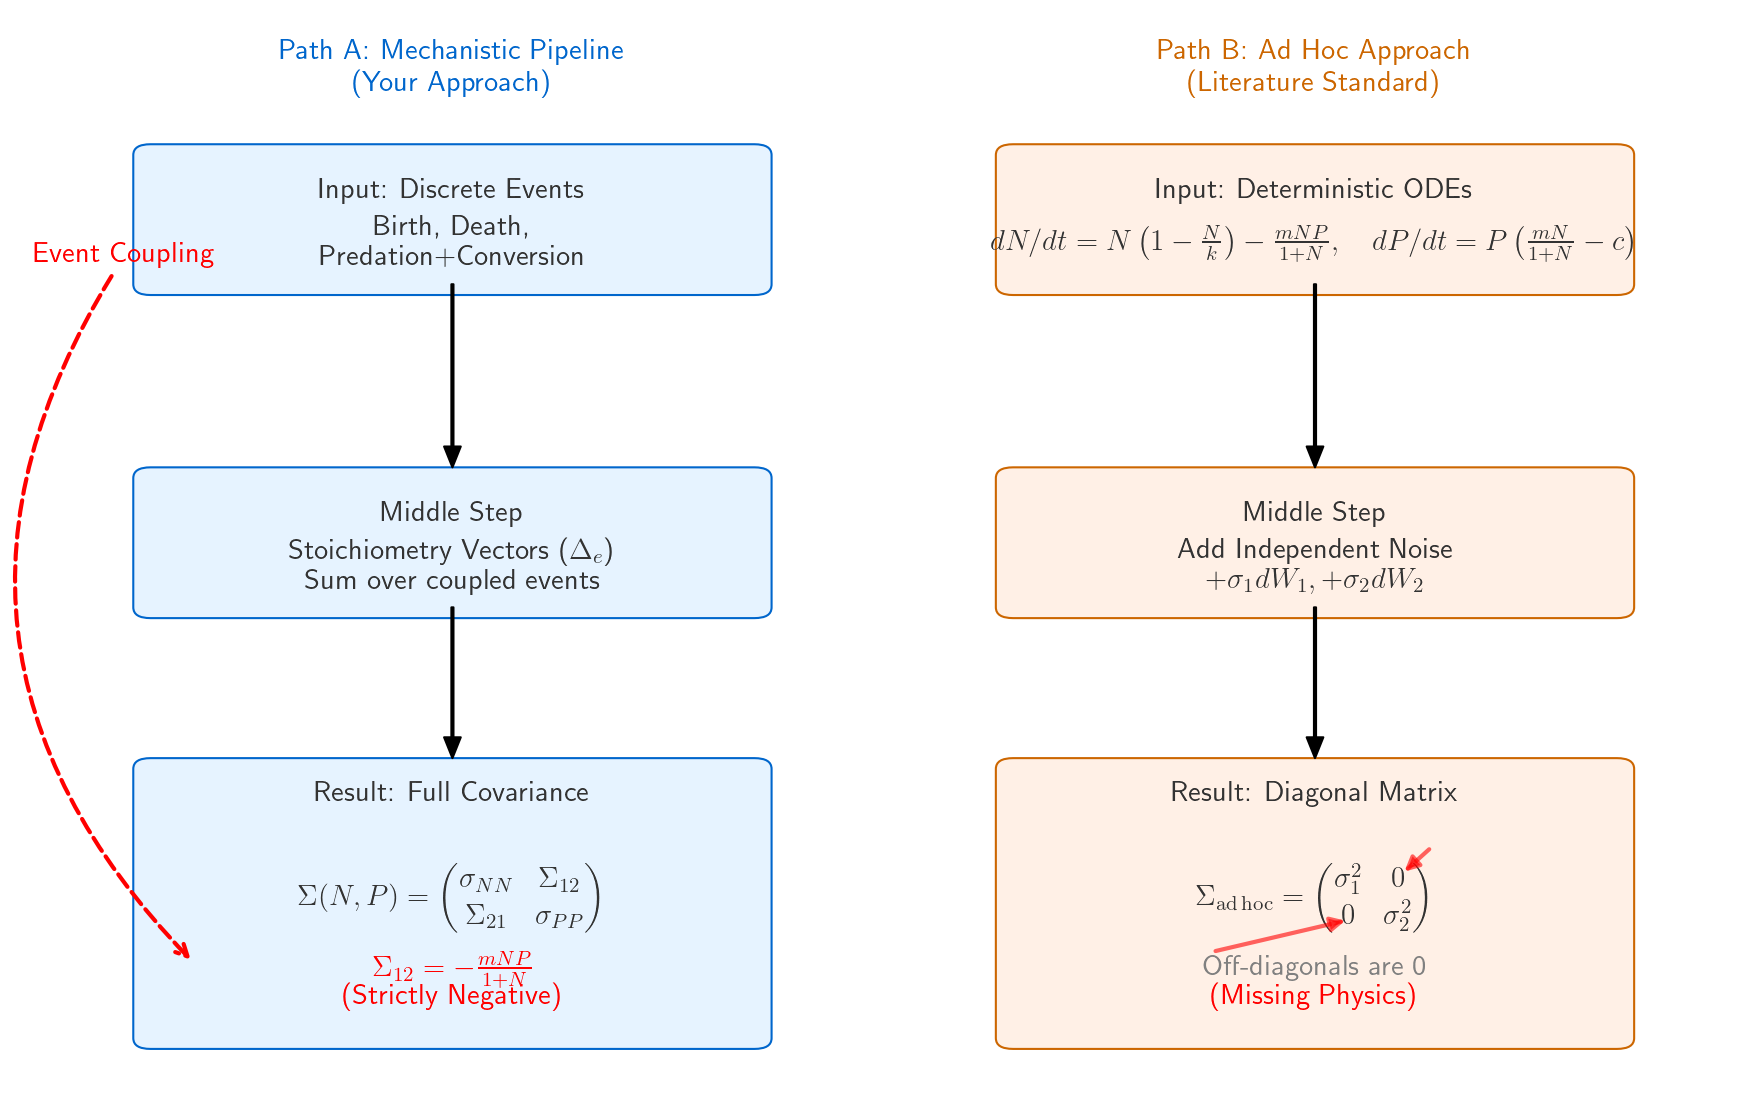

In [74]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib as mpl
from pathlib import Path

# Output directory for all PDF figures
OUT_DIR = Path(r"C:\Users\lenovo\Downloads")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Paper-style readability defaults (kept TeX-safe)
mpl.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'legend.title_fontsize': 12,
    'lines.linewidth': 2.0,
    'lines.markersize': 7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# Set to True AFTER installing MiKTeX/TeX Live (pdflatex).
# - False: uses Matplotlib mathtext + plain-text matrix fallback (no external dependencies)
# - True : uses real LaTeX (supports \begin{pmatrix}...\end{pmatrix})
USE_TEX = True

mpl.rcParams.update({"text.usetex": USE_TEX})
if USE_TEX:
    # pmatrix requires amsmath
    mpl.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\usepackage{amssymb}"

def draw_concept_diagram():
    # Setup the figure
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

    # Style constants
    box_width = 3.5
    box_height = 1.2
    path_a_color = '#E6F3FF'  # Light blue for Mechanistic
    path_b_color = '#FFF0E6'  # Light orange for Ad Hoc
    border_a = '#0066CC'
    border_b = '#CC6600'
    text_color = '#333333'

    # Helper: box center coordinates
    def box_center(x, y, w, h):
        return (x + w/2.0, y + h/2.0)

    # --- TITLES ---
    ax.text(2.5, 9.5, "Path A: Mechanistic Pipeline\n(Your Approach)", 
            ha='center', va='center', fontweight='bold', color=border_a)
    ax.text(7.5, 9.5, "Path B: Ad Hoc Approach\n(Literature Standard)", 
            ha='center', va='center', fontweight='bold', color=border_b)

    # --- PATH A: NODES ---
    
    # Node A1: Input
    rect_a1 = patches.FancyBboxPatch((0.75, 7.5), box_width, box_height, 
                                     boxstyle="round,pad=0.1", ec=border_a, fc=path_a_color)
    ax.add_patch(rect_a1)
    a1x, a1y = box_center(0.75, 7.5, box_width, box_height)
    ax.text(a1x, a1y + 0.22*box_height, "Input: Discrete Events", ha='center', va='center', fontweight='bold', color=text_color)
    ax.text(a1x, a1y - 0.18*box_height, "Birth, Death,\nPredation+Conversion", ha='center', va='center', color=text_color)

    # Node A2: Middle Step
    rect_a2 = patches.FancyBboxPatch((0.75, 4.5), box_width, box_height, 
                                     boxstyle="round,pad=0.1", ec=border_a, fc=path_a_color)
    ax.add_patch(rect_a2)
    a2x, a2y = box_center(0.75, 4.5, box_width, box_height)
    ax.text(a2x, a2y + 0.22*box_height, "Middle Step", ha='center', va='center', fontweight='bold', color=text_color)
    ax.text(a2x, a2y - 0.18*box_height, r"Stoichiometry Vectors ($\Delta_e$)" + "\nSum over coupled events", 
            ha='center', va='center', color=text_color)

    # Node A3: Result (The Matrix)
    rect_a3 = patches.FancyBboxPatch((0.75, 0.5), box_width, 2.5, 
                                     boxstyle="round,pad=0.1", ec=border_a, fc=path_a_color)
    ax.add_patch(rect_a3)
    ax.text(2.5, 2.7, "Result: Full Covariance", ha='center', fontweight='bold', color=text_color)
    
    # Draw Matrix A inside Node A3
    if USE_TEX:
        matrix_a = r"$\Sigma(N,P)=\begin{pmatrix}\sigma_{NN} & \Sigma_{12}\\\Sigma_{21} & \sigma_{PP}\end{pmatrix}$"
        ax.text(2.5, 1.80, matrix_a, ha='center', va='center', color=text_color)
    else:
        matrix_a = "Σ(N,P) = ( σ_NN   Σ_12 )\n         ( Σ_21   σ_PP )"
        ax.text(2.5, 1.80, matrix_a, ha='center', va='center', family='monospace', color=text_color)
    # Highlight specific term
    ax.text(2.5, 1.08, r"$\Sigma_{12} = -\frac{mNP}{1+N}$", ha='center', color='red', fontweight='bold')
    ax.text(2.5, 0.82, "(Strictly Negative)", ha='center', color='red')

    # --- PATH B: NODES ---

    # Node B1: Input
    rect_b1 = patches.FancyBboxPatch((5.75, 7.5), box_width, box_height, 
                                     boxstyle="round,pad=0.1", ec=border_b, fc=path_b_color)
    ax.add_patch(rect_b1)
    b1x, b1y = box_center(5.75, 7.5, box_width, box_height)
    ax.text(b1x, b1y + 0.22*box_height, "Input: Deterministic ODEs", ha='center', va='center', fontweight='bold', color=text_color)
    ax.text(b1x, b1y - 0.18*box_height, r"$dN/dt= N\left(1-\frac{N}{k}\right)-\frac{mNP}{1+N},\quad dP/dt= P\left(\frac{mN}{1+N}-c\right)$", ha='center', va='center', color=text_color)

    # Node B2: Middle Step
    rect_b2 = patches.FancyBboxPatch((5.75, 4.5), box_width, box_height, 
                                     boxstyle="round,pad=0.1", ec=border_b, fc=path_b_color)
    ax.add_patch(rect_b2)
    b2x, b2y = box_center(5.75, 4.5, box_width, box_height)
    ax.text(b2x, b2y + 0.22*box_height, "Middle Step", ha='center', va='center', fontweight='bold', color=text_color)
    ax.text(b2x, b2y - 0.18*box_height, "Add Independent Noise\n" + r"$+\sigma_1 dW_1, +\sigma_2 dW_2$", 
            ha='center', va='center', color=text_color)

    # Node B3: Result (The Matrix)
    rect_b3 = patches.FancyBboxPatch((5.75, 0.5), box_width, 2.5, 
                                     boxstyle="round,pad=0.1", ec=border_b, fc=path_b_color)
    ax.add_patch(rect_b3)
    ax.text(7.5, 2.7, "Result: Diagonal Matrix", ha='center', fontweight='bold', color=text_color)

    # Draw Matrix B inside Node B3
    if USE_TEX:
        matrix_b = r"$\Sigma_{\mathrm{ad\,hoc}}=\begin{pmatrix}\sigma_1^2 & 0\\0 & \sigma_2^2\end{pmatrix}$"
        ax.text(7.5, 1.80, matrix_b, ha='center', va='center', color=text_color)
    else:
        matrix_b = "Σ_adhoc = ( σ1^2   0 )\n          ( 0   σ2^2 )"
        ax.text(7.5, 1.80, matrix_b, ha='center', va='center', family='monospace', color=text_color)
    
    # Missing Physics label
    ax.text(7.5, 1.08, "Off-diagonals are 0", ha='center', color='gray', fontweight='bold')
    
    # Two arrows pointing at the off-diagonal zeros
    ax.annotate('', xy=(8.00, 2.02), xytext=(8.18, 2.28),
                arrowprops=dict(arrowstyle='-|>', color='red', lw=2, alpha=0.6))
    ax.annotate('', xy=(7.7, 1.60), xytext=(6.90, 1.30),
                arrowprops=dict(arrowstyle='-|>', color='red', lw=2, alpha=0.6))
    ax.text(7.5, 0.82, "(Missing Physics)", ha='center', color='red')

    # --- ARROWS ---
    
    arrow_props = dict(facecolor='black', width=1, headwidth=8, headlength=10)
    
    # Path A Arrows
    ax.annotate('', xy=(2.5, 5.8), xytext=(2.5, 7.5), arrowprops=arrow_props)
    ax.annotate('', xy=(2.5, 3.1), xytext=(2.5, 4.5), arrowprops=arrow_props)

    # Path B Arrows
    ax.annotate('', xy=(7.5, 5.8), xytext=(7.5, 7.5), arrowprops=arrow_props)
    ax.annotate('', xy=(7.5, 3.1), xytext=(7.5, 4.5), arrowprops=arrow_props)

    # --- SPECIAL HIGHLIGHT ARROW (The "Mechanistic Link") ---
    # Connecting "Predation" in A1 to "Sigma_12" in A3
    
    # We use a curved arrow traversing the diagram to show the direct link
    # From (2.5, 7.6) [Predation text] to (2.5, 1.2) [Matrix term]
    # But we want to bypass the middle box visually or go through it. 
    # Let's draw a distinct red dotted arrow on the side.
    
    ax.annotate('Event Coupling', 
                xy=(1.0, 1.2), xycoords='data',
                xytext=(0.6, 7.7), textcoords='data',
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.4", 
                                color='red', lw=2, ls='--'),
                color='red', fontweight='bold', ha='center')

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    outpath = OUT_DIR / 'Fig2.pdf'
    fig.savefig(outpath, bbox_inches='tight')
    print(f'Saved PDF to: {outpath}')
    plt.show()

if __name__ == "__main__":
    draw_concept_diagram()

Saved PDF to: C:\Users\lenovo\Downloads\Fig3.pdf


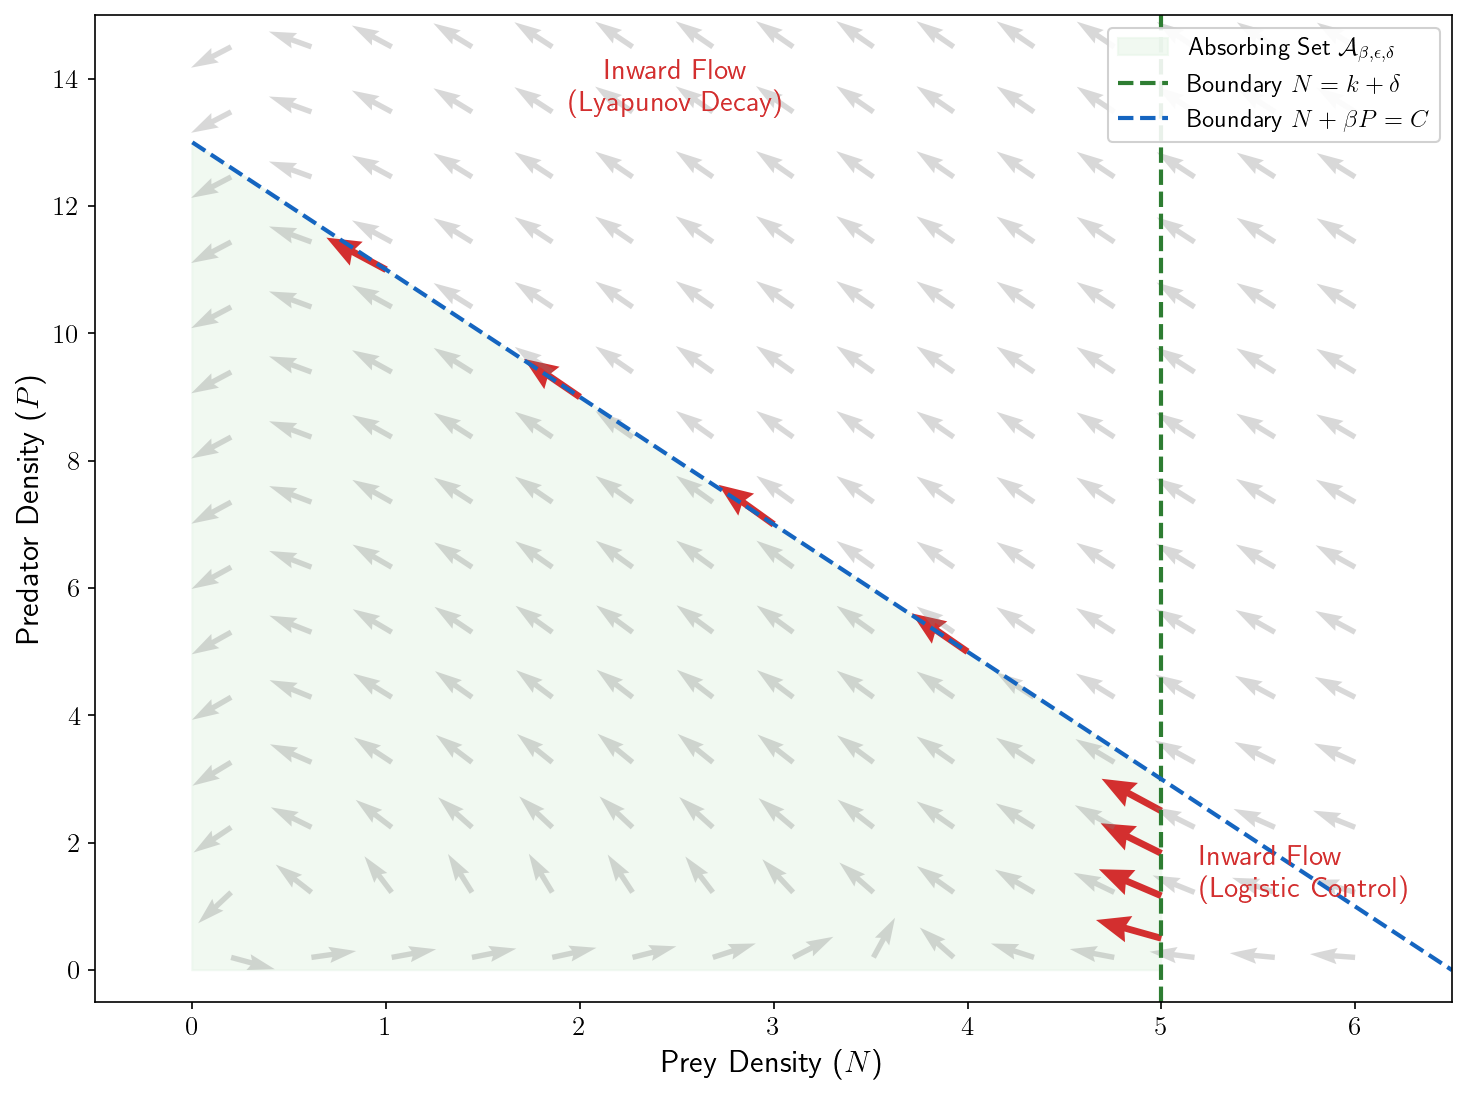

In [73]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from pathlib import Path

OUT_DIR = Path(r"C:\Users\lenovo\Downloads")
OUT_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'legend.title_fontsize': 12,
    'lines.linewidth': 2.0,
    'lines.markersize': 7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

def draw_absorbing_set():
    # --- 1. MODEL PARAMETERS ---
    # Choose standard parameters where the absorbing set is clear
    k = 4.0      # Carrying capacity
    m = 2.0      # Max predation rate
    c = 0.5      # Predator death rate
    beta = 0.5   # Weighting factor for Lyapunov function S = N + beta*P
    
    # Parameters for the absorbing set boundary (epsilon, delta)
    delta = 1.0
    epsilon = 2.0
    
    # Calculate the theoretical bound for S_beta
    # From Lemma 2.3: max value approx k(1+c)^2 / (4c)
    bound_S_base = (k * (1 + c)**2) / (4 * c)
    bound_S = bound_S_base + epsilon  # The constant C in N + beta*P <= C
    
    bound_N = k + delta
    
    # --- 2. SETUP PLOT ---
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Set limits slightly larger than the absorbing set
    x_limit = bound_N + 1.5
    y_limit = (bound_S / beta) + 2
    ax.set_xlim(-0.5, x_limit)
    ax.set_ylim(-0.5, y_limit)
    
    # --- 3. DEFINE VECTOR FIELD (Rosenzweig-MacArthur) ---
    def vector_field(N, P):
        # Avoid division by zero
        if N < 0: N = 0
        if P < 0: P = 0
        
        # dN/dt = N(1 - N/k) - mNP/(1+N)
        dN = N * (1 - N/k) - (m * N * P) / (1 + N)
        
        # dP/dt = P(mN/(1+N) - c)
        dP = P * ((m * N) / (1 + N) - c)
        return dN, dP

    # --- 4. DRAW THE ABSORBING SET REGION ---
    # The set is defined by: 0 <= N <= bound_N  AND  N + beta*P <= bound_S
    
    # Vertices of the polygon
    # 1. Origin
    p1 = (0, 0)
    # 2. On N-axis
    p2 = (bound_N, 0)
    # 3. Intersection of N=bound_N and N+beta*P=bound_S
    # bound_N + beta*P = bound_S => P = (bound_S - bound_N)/beta
    p_intersect_y = (bound_S - bound_N) / beta
    p3 = (bound_N, p_intersect_y)
    # 4. On P-axis (N=0) => beta*P = bound_S => P = bound_S/beta
    p4 = (0, bound_S / beta)
    
    # Create polygon patch
    polygon = plt.Polygon([p1, p2, p3, p4], color='#E8F5E9', alpha=0.6, label='Absorbing Set $\\mathcal{A}_{\\beta,\\epsilon,\\delta}$')
    ax.add_patch(polygon)
    
    # --- 5. DRAW BOUNDARY LINES ---
    # Vertical Line: N = k + delta
    ax.axvline(x=bound_N, color='#2E7D32', linestyle='--', linewidth=2, label=r'Boundary $N = k+\delta$')
    
    # Slanted Line: N + beta*P = C
    # P = (C - N)/beta
    x_vals = np.linspace(0, bound_S, 100)
    y_vals = (bound_S - x_vals) / beta
    # Clip y to be positive
    valid = y_vals >= 0
    ax.plot(x_vals[valid], y_vals[valid], color='#1565C0', linestyle='--', linewidth=2, label=r'Boundary $N + \beta P = C$')

    # --- 6. PLOT VECTORS ON THE BOUNDARIES (To show inward flow) ---
    
    # A. Vertical Boundary vectors (N = bound_N)
    # We pick a few points along the vertical line segment of the set
    y_points_vert = np.linspace(0.5, p_intersect_y - 0.5, 4)
    for y in y_points_vert:
        u, v = vector_field(bound_N, y)
        # Normalize length for uniform visualization
        norm = np.sqrt(u**2 + v**2)
        ax.quiver(bound_N, y, u/norm, v/norm, color='#D32F2F', scale=20, width=0.005, headwidth=4)

    # B. Slanted Boundary vectors (N + beta*P = C)
    # Pick points along the slanted top edge
    x_points_slant = np.linspace(1, bound_N - 1, 4)
    for x in x_points_slant:
        y = (bound_S - x) / beta
        u, v = vector_field(x, y)
        norm = np.sqrt(u**2 + v**2)
        ax.quiver(x, y, u/norm, v/norm, color='#D32F2F', scale=20, width=0.005, headwidth=4)

    # --- 7. GENERAL VECTOR FIELD BACKGROUND ---
    # Create a grid
    grid_x, grid_y = np.meshgrid(np.linspace(0.2, x_limit-0.5, 15), 
                                 np.linspace(0.2, y_limit-0.5, 15))
    u_grid = np.zeros_like(grid_x)
    v_grid = np.zeros_like(grid_y)
    
    for i in range(grid_x.shape[0]):
        for j in range(grid_x.shape[1]):
            u, v = vector_field(grid_x[i,j], grid_y[i,j])
            # Normalize just for directionality
            n = np.sqrt(u**2 + v**2)
            if n > 0:
                u_grid[i,j] = u/n
                v_grid[i,j] = v/n
                
    ax.quiver(grid_x, grid_y, u_grid, v_grid, color='gray', alpha=0.3, scale=30)

    # --- 8. LABELS AND ANNOTATIONS ---
    ax.set_xlabel('Prey Density ($N$)')
    ax.set_ylabel('Predator Density ($P$)')
    
    # Annotation for Inward Flow
    ax.text(bound_N + 0.2, p_intersect_y/2, 'Inward Flow\n(Logistic Control)', 
            color='#D32F2F', style='italic', va='center')
            
    ax.text(bound_N/2, (bound_S/beta) + 0.5, 'Inward Flow\n(Lyapunov Decay)', 
            color='#D32F2F', style='italic', ha='center')

    # Legend
    ax.legend(loc='upper right', framealpha=0.9)
    
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    outpath = OUT_DIR / 'Fig3.pdf'
    fig.savefig(outpath, bbox_inches='tight')
    print(f'Saved PDF to: {outpath}')
    plt.show()

if __name__ == "__main__":
    draw_absorbing_set()

Saved PDF to: C:\Users\lenovo\Downloads\Fig4.pdf


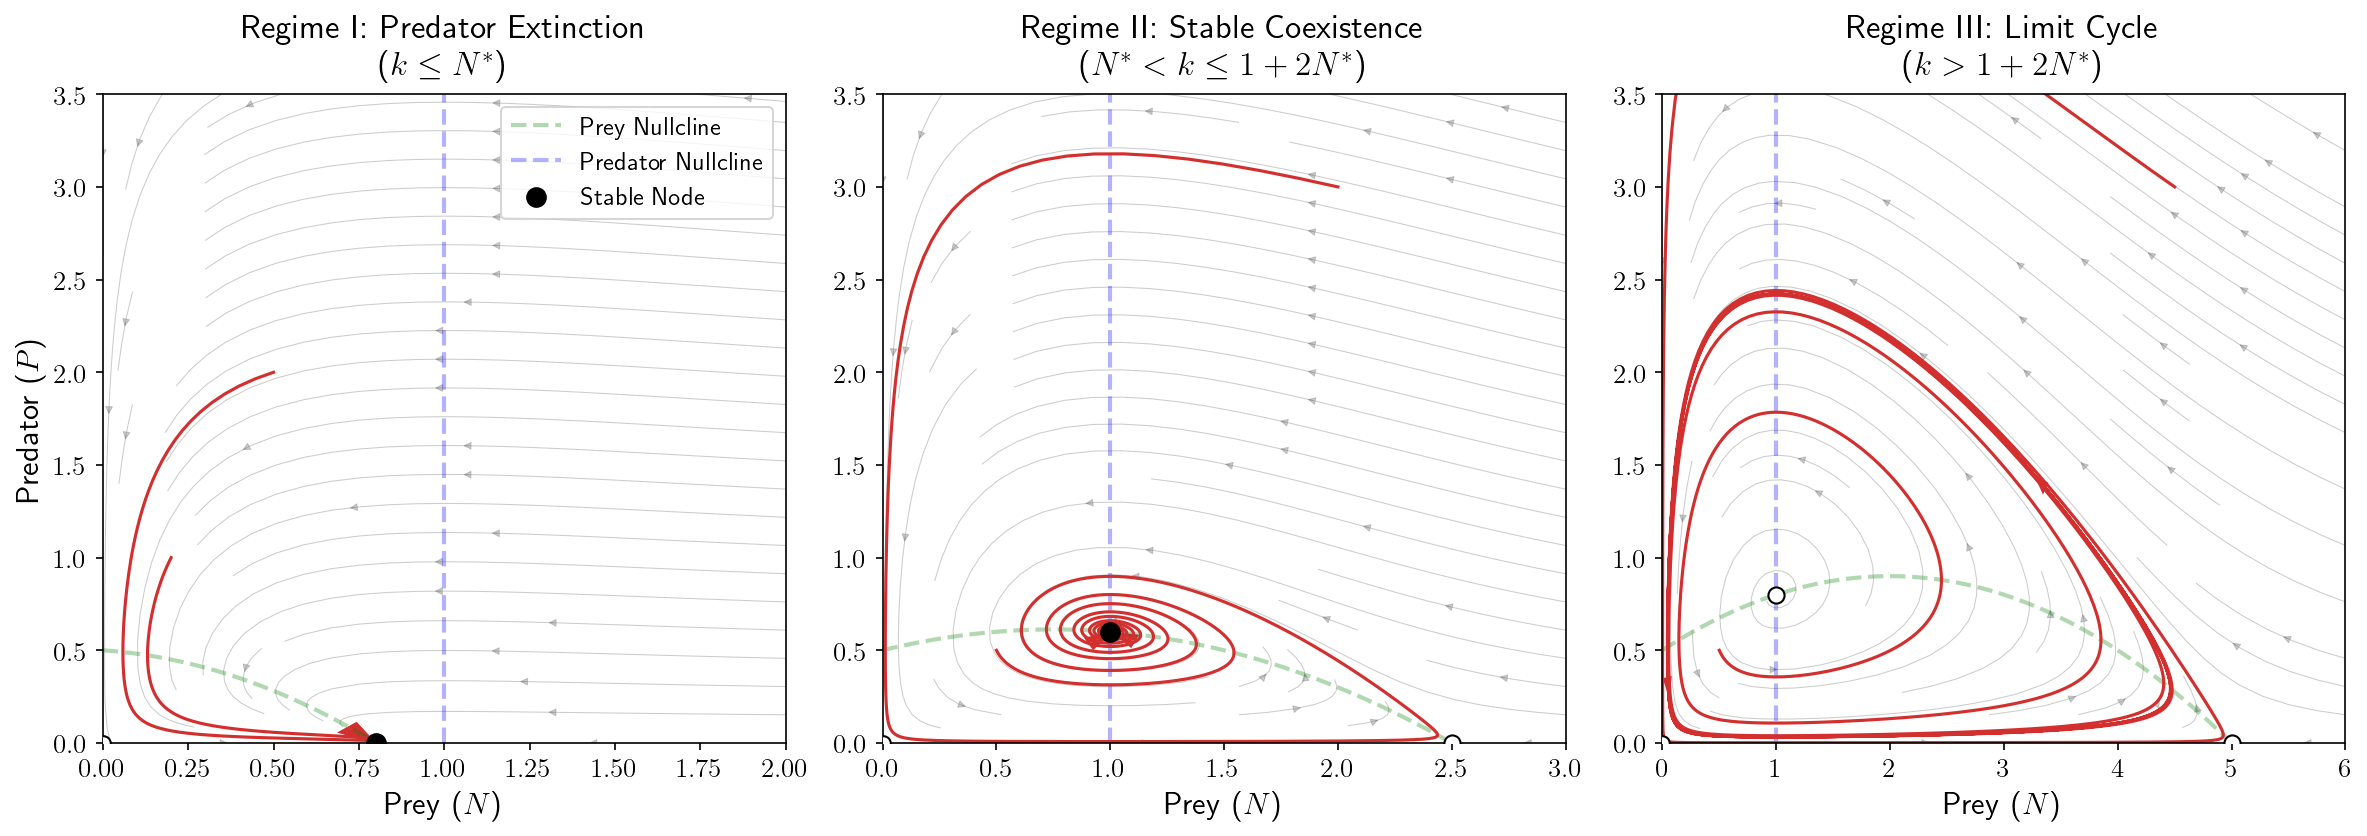

In [75]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
import matplotlib as mpl
from pathlib import Path

OUT_DIR = Path(r"C:\Users\lenovo\Downloads")
OUT_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'legend.title_fontsize': 12,
    'lines.linewidth': 2.0,
    'lines.markersize': 7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

def draw_dynamic_regimes():
    # --- 1. MODEL DEFINITION ---
    # Rosenzweig-MacArthur ODEs
    def model(z, t, k, m, c):
        N, P = z
        if N < 0: N = 0
        if P < 0: P = 0
        
        dNdt = N * (1 - N/k) - (m * N * P) / (1 + N)
        dPdt = P * ((m * N) / (1 + N) - c)
        return [dNdt, dPdt]

    # --- 2. PARAMETERS ---
    # Fixed parameters for N* calculation
    m = 2.0
    c = 1.0
    # N* = c / (m - c) = 1.0 / (1.0) = 1.0
    N_star = c / (m - c)
    
    # Bifurcation Threshold for k: k_crit = 1 + 2*N* = 1 + 2(1) = 3.0
    
    # We choose 3 k values to represent the 3 regimes:
    # 1. k < N* (Predator Extinction)
    # 2. N* < k < k_crit (Stable Coexistence)
    # 3. k > k_crit (Limit Cycle / Paradox of Enrichment)
    scenarios = [
        {"k": 0.8, "title": "Regime I: Predator Extinction\n($k \\leq N^*$)", "type": "extinction"},
        {"k": 2.5, "title": "Regime II: Stable Coexistence\n($N^* < k \\leq 1+2N^*$)", "type": "stable"},
        {"k": 5.0, "title": "Regime III: Limit Cycle\n($k > 1+2N^*$)", "type": "cycle"}
    ]

    # --- 3. PLOTTING SETUP ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 5.8))
    
    # Common grid for streamplots
    y_max = 3.5
    x_max = 6.0
    
    # Time settings for integration
    t = np.linspace(0, 100, 2000)

    for i, scen in enumerate(scenarios):
        ax = axes[i]
        k_val = scen["k"]
        
        # Adjust x limit based on k for better view
        current_x_max = max(k_val * 1.2, 2.0)
        ax.set_xlim(0, current_x_max)
        ax.set_ylim(0, y_max)
        
        # A. Streamplot (Vector Field Background)
        # ---------------------------------------
        Y, X = np.mgrid[0:y_max:20j, 0:current_x_max:20j]
        U = X * (1 - X/k_val) - (m * X * Y) / (1 + X)
        V = Y * ((m * X) / (1 + X) - c)
        
        # Normalize arrows
        speed = np.sqrt(U**2 + V**2)
        lw = 5*speed / speed.max()
        # streamplot() does not accept alpha= on some Matplotlib versions; use RGBA instead
        ax.streamplot(X, Y, U, V, density=0.8, color=(0.5, 0.5, 0.5, 0.4), linewidth=0.5, arrowsize=0.8)

        # B. Nullclines (Visual Guides)
        # -----------------------------
        # N-nullcline: P = (1+N)/m * (1 - N/k)
        n_vals = np.linspace(0, k_val, 100)
        p_null = (1 + n_vals)/m * (1 - n_vals/k_val)
        ax.plot(n_vals, p_null, '--', color='green', alpha=0.3, label='Prey Nullcline')
        
        # P-nullcline: N = N* (Vertical line)
        if N_star < current_x_max:
            ax.axvline(x=N_star, color='blue', linestyle='--', alpha=0.3, label='Predator Nullcline')

        # C. Sample Trajectories
        # ----------------------
        # Choose start points based on regime to show convergence clearly
        start_points = []
        if scen["type"] == "extinction":
            start_points = [(0.2, 1.0), (0.5, 2.0)]
        elif scen["type"] == "stable":
            start_points = [(0.5, 0.5), (2.0, 3.0)]
        else: # cycle
            start_points = [(0.5, 0.5), (4.5, 3.0)] # Inside and outside cycle

        for start in start_points:
            sol = odeint(model, start, t, args=(k_val, m, c))
            ax.plot(sol[:, 0], sol[:, 1], color='#D32F2F', linewidth=1.5)
            # Add arrow head at end
            ax.arrow(sol[-2, 0], sol[-2, 1], sol[-1, 0]-sol[-2, 0], sol[-1, 1]-sol[-2, 1], 
                     shape='full', lw=0, length_includes_head=True, head_width=0.08, color='#D32F2F')

        # D. Equilibrium Points
        # ---------------------
        # 1. Origin (0,0) - Always saddle
        ax.scatter(0, 0, color='white', edgecolor='black', zorder=5)
        
        # 2. Prey-only (k, 0)
        if scen["type"] == "extinction":
            # Stable
            ax.scatter(k_val, 0, color='black', s=80, zorder=5, label='Stable Node')
        else:
            # Unstable (Saddle)
            ax.scatter(k_val, 0, color='white', edgecolor='black', s=60, zorder=5)

        # 3. Coexistence (N*, P*)
        if scen["type"] != "extinction":
            P_star = (1 + N_star)/m * (1 - N_star/k_val)
            if scen["type"] == "stable":
                # Stable Focus
                ax.scatter(N_star, P_star, color='black', s=80, zorder=5, label='Stable Equilibrium')
            else:
                # Unstable Focus (surrounded by limit cycle)
                ax.scatter(N_star, P_star, color='white', edgecolor='black', s=60, zorder=5, label='Unstable Point')

        # E. Styling
        ax.set_title(scen["title"], fontweight='bold', pad=10)
        ax.set_xlabel('Prey ($N$)')
        if i == 0:
            ax.set_ylabel('Predator ($P$)')
            ax.legend(loc='upper right')
    
    plt.tight_layout()
    outpath = OUT_DIR / 'Fig4.pdf'
    fig.savefig(outpath, bbox_inches='tight')
    print(f'Saved PDF to: {outpath}')
    plt.show()

if __name__ == "__main__":
    draw_dynamic_regimes()

Saved PDF to: C:\Users\lenovo\Downloads\Fig5.pdf


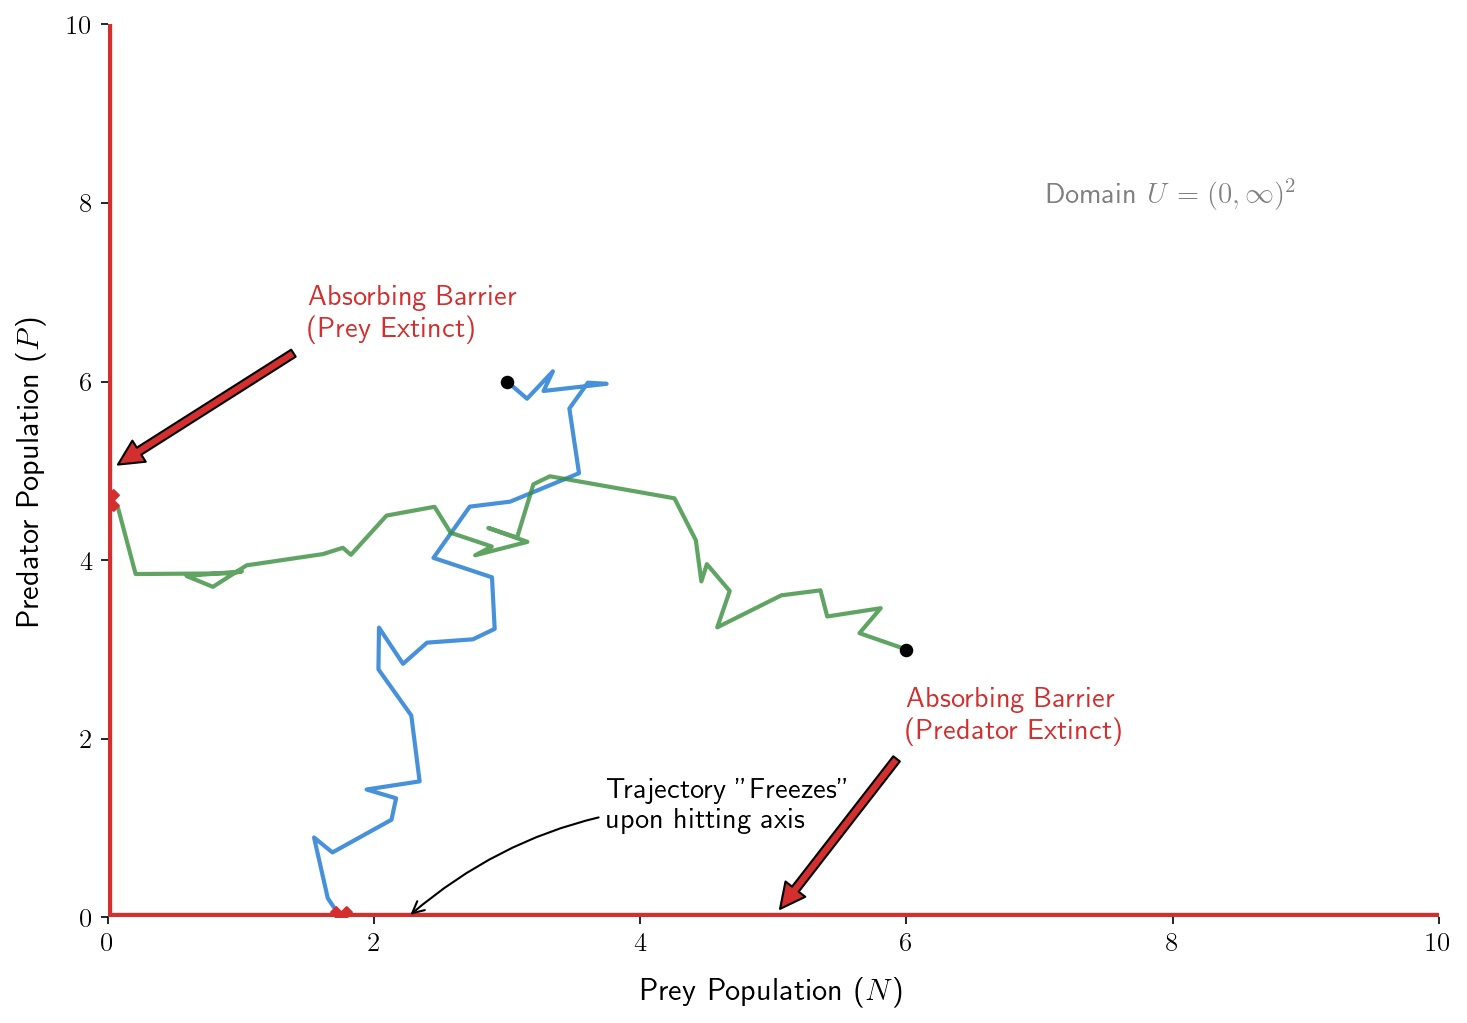

In [76]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from pathlib import Path

OUT_DIR = Path(r"C:\Users\lenovo\Downloads")
OUT_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'legend.title_fontsize': 12,
    'lines.linewidth': 2.0,
    'lines.markersize': 7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

def draw_phase_plane_schematic():
    # Setup
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Domain limits
    xlim = (0, 10)
    ylim = (0, 10)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    
    # --- 1. THE BOUNDARY (Absorbing Axes) ---
    # Draw thicker red lines for axes to represent absorption
    ax.axhline(0, color='#D32F2F', linewidth=4, zorder=1) # x-axis (P=0)
    ax.axvline(0, color='#D32F2F', linewidth=4, zorder=1) # y-axis (N=0)
    
    # Remove top and right spines for a cleaner "quadrant" look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False) # Hiding default spines to rely on the red axes
    ax.spines['bottom'].set_visible(False)

    # Labels
    ax.set_xlabel('Prey Population ($N$)', labelpad=10)
    ax.set_ylabel('Predator Population ($P$)', labelpad=10)
    
    # --- 2. GENERATE SAMPLE TRAJECTORIES ---
    np.random.seed(42) # For reproducibility
    steps = 100
    
    # Helper to generate a path that hits a specific axis
    def generate_path(start, target_axis='x'):
        path_x = [start[0]]
        path_y = [start[1]]
        
        curr_x, curr_y = start
        absorbed = False
        
        for _ in range(steps):
            if absorbed:
                # FREEZE behavior
                path_x.append(curr_x)
                path_y.append(curr_y)
                continue
                
            # Simple random walk step
            dx = np.random.normal(0, 0.3)
            dy = np.random.normal(0, 0.3)
            
            # Add a slight drift towards the target axis to ensure intersection
            if target_axis == 'x': # Target P=0
                dy -= 0.15 
            elif target_axis == 'y': # Target N=0
                dx -= 0.15
            
            curr_x += dx
            curr_y += dy
            
            # Check absorption
            if curr_x <= 0:
                curr_x = 0
                absorbed = True
            if curr_y <= 0:
                curr_y = 0
                absorbed = True
                
            path_x.append(curr_x)
            path_y.append(curr_y)
            
        return np.array(path_x), np.array(path_y)

    # Path 1: Predator Extinction (Hits P=0 / x-axis)
    p1_x, p1_y = generate_path((3, 6), target_axis='x')
    
    # Path 2: Prey Extinction (Hits N=0 / y-axis)
    p2_x, p2_y = generate_path((6, 3), target_axis='y')
    
    # Path 3: Survival (Interior)
    # Just a wandering path
    p3_x = [5]
    p3_y = [8]
    for _ in range(steps):
        p3_x.append(p3_x[-1] + np.random.normal(0, 0.2))
        p3_y.append(p3_y[-1] + np.random.normal(0, 0.2))

    # --- 3. PLOT TRAJECTORIES ---
    
    # Plot Path 1 (Predator Die-out)
    ax.plot(p1_x, p1_y, color='#1976D2', alpha=0.8, linewidth=2, label='Predator Extinction')
    ax.scatter(p1_x[0], p1_y[0], color='black', s=30, zorder=3) # Start
    # Mark the absorption point
    abs_idx_1 = np.where(p1_y == 0)[0][0]
    ax.scatter(p1_x[abs_idx_1], p1_y[abs_idx_1], color='#D32F2F', s=100, marker='X', zorder=5)
    
    # Plot Path 2 (Prey Die-out)
    ax.plot(p2_x, p2_y, color='#388E3C', alpha=0.8, linewidth=2, label='Prey Extinction')
    ax.scatter(p2_x[0], p2_y[0], color='black', s=30, zorder=3) # Start
    # Mark absorption point
    abs_idx_2 = np.where(p2_x == 0)[0][0]
    ax.scatter(p2_x[abs_idx_2], p2_y[abs_idx_2], color='#D32F2F', s=100, marker='X', zorder=5)

    # --- 4. ANNOTATIONS ---
    
    # Domain Label
    ax.text(8, 8, r"Domain $U = (0, \infty)^2$", color='gray', ha='center')
    
    # Boundary Annotations
    ax.annotate('Absorbing Barrier\n(Prey Extinct)', xy=(0, 5), xytext=(1.5, 6.5),
                arrowprops=dict(facecolor='#D32F2F', shrink=0.05),
                color='#D32F2F', fontweight='bold')
                
    ax.annotate('Absorbing Barrier\n(Predator Extinct)', xy=(5, 0), xytext=(6, 2),
                arrowprops=dict(facecolor='#D32F2F', shrink=0.05),
                color='#D32F2F', fontweight='bold')

    # Frozen state annotation
    ax.annotate('Trajectory "Freezes"\nupon hitting axis', xy=(p1_x[abs_idx_1]+0.5, 0), xytext=(p1_x[abs_idx_1]+2, 1),
                arrowprops=dict(arrowstyle="->", color='black', connectionstyle="arc3,rad=.2"),
                style='italic')

    plt.tight_layout(rect=[0, 0.06, 1, 0.94])
    outpath = OUT_DIR / 'Fig5.pdf'
    fig.savefig(outpath, bbox_inches='tight')
    print(f'Saved PDF to: {outpath}')
    plt.show()

if __name__ == "__main__":
    draw_phase_plane_schematic()

Saved PDF to: C:\Users\lenovo\Downloads\Fig6.pdf


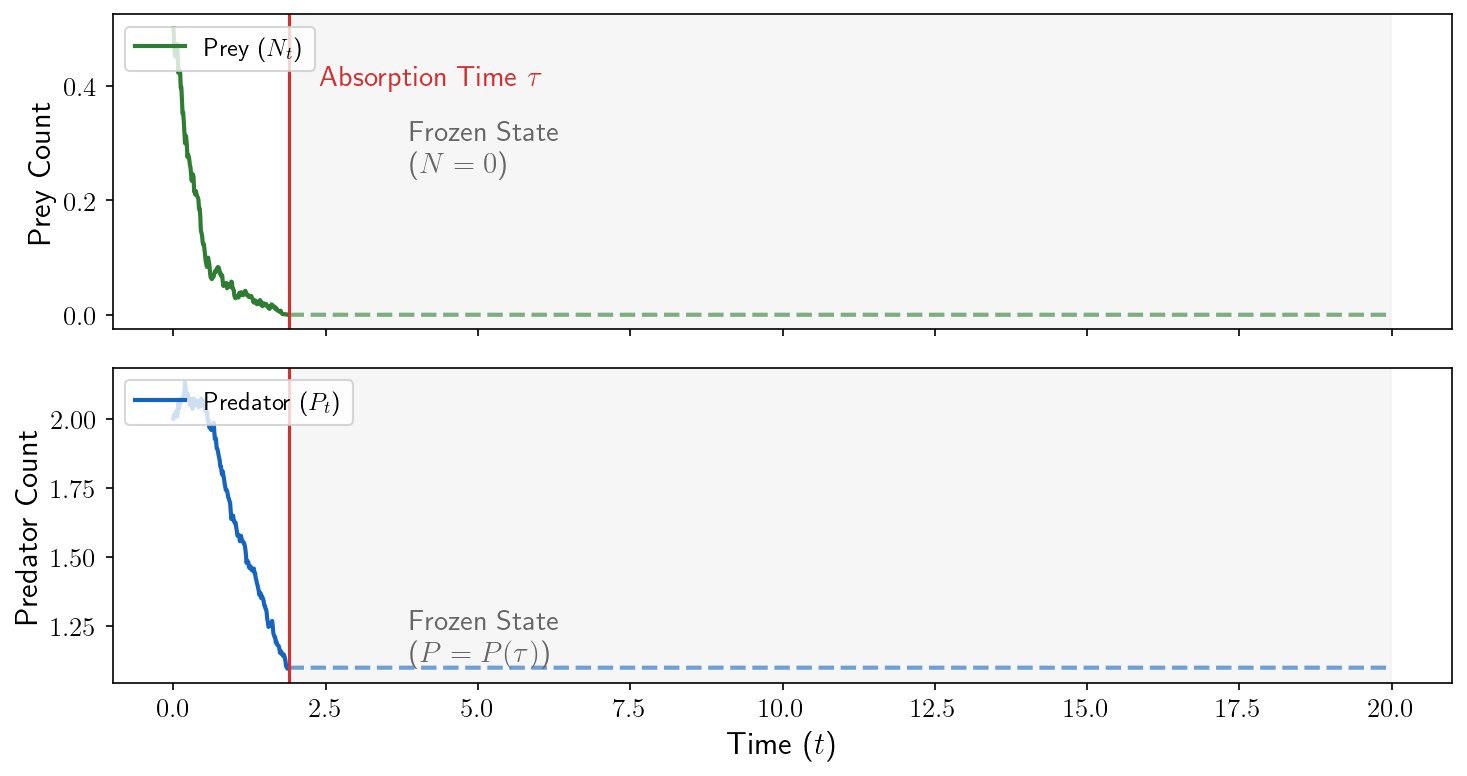

In [77]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from pathlib import Path

OUT_DIR = Path(r"C:\Users\lenovo\Downloads")
OUT_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'legend.title_fontsize': 12,
    'lines.linewidth': 2.0,
    'lines.markersize': 7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

def draw_absorption_timeseries():
    # --- 1. SIMULATE ONE PATH UNTIL ABSORPTION ---
    # Parameters
    k = 4.0
    m = 2.0
    c = 0.5
    omega = 100.0 # Moderate noise
    rho = 1.0 / np.sqrt(omega)
    
    dt = 0.01
    max_steps = 2000
    
    # Storage
    N = np.zeros(max_steps)
    P = np.zeros(max_steps)
    time = np.arange(max_steps) * dt
    
    # Initial Condition (Low prey to trigger extinction)
    N[0] = 0.5
    P[0] = 2.0
    
    # Drift and Diffusion functions
    def get_drift(n, p):
        dn = n * (1 - n/k) - (m * n * p) / (1 + n)
        dp = p * ((m * n) / (1 + n) - c)
        return dn, dp
        
    tau_idx = -1
    
    np.random.seed(42) # Fixed seed for reproducibility
    
    for i in range(max_steps - 1):
        n_curr, p_curr = N[i], P[i]
        
        # Check absorption
        if n_curr <= 0 or p_curr <= 0:
            # FREEZE
            N[i+1:] = n_curr
            P[i+1:] = p_curr
            tau_idx = i
            break
            
        # Update (Euler-Maruyama with 4-channel noise)
        # Rates
        r_birth = max(0, n_curr)
        r_comp = max(0, n_curr**2 / k)
        r_death = max(0, c * p_curr)
        r_pred = max(0, (m * n_curr * p_curr) / (1 + n_curr))
        
        # Noise
        dW = np.random.normal(0, np.sqrt(dt), 4)
        
        # Matrix multiplication L_ev * dW
        # N noise: sqrt(r_B)*dW1 - sqrt(r_C)*dW2 - sqrt(r_E)*dW4
        # P noise: -sqrt(r_D)*dW3 + sqrt(r_E)*dW4
        
        noise_n = (np.sqrt(r_birth)*dW[0] - np.sqrt(r_comp)*dW[1] - np.sqrt(r_pred)*dW[3])
        noise_p = (-np.sqrt(r_death)*dW[2] + np.sqrt(r_pred)*dW[3])
        
        mu_n, mu_p = get_drift(n_curr, p_curr)
        
        N[i+1] = n_curr + mu_n*dt + rho*noise_n
        P[i+1] = p_curr + mu_p*dt + rho*noise_p
        
        # Hard check for next step boundary crossing
        if N[i+1] <= 0: N[i+1] = 0
        if P[i+1] <= 0: P[i+1] = 0
    
    if tau_idx == -1:
        tau_idx = max_steps - 1

    # --- 2. PLOTTING ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    
    # Plot Pre-Absorption (Active)
    t_active = time[:tau_idx+1]
    ax1.plot(t_active, N[:tau_idx+1], color='#2E7D32', lw=2, label='Prey ($N_t$)')
    ax2.plot(t_active, P[:tau_idx+1], color='#1565C0', lw=2, label='Predator ($P_t$)')
    
    # Plot Post-Absorption (Frozen)
    t_frozen = time[tau_idx:]
    ax1.plot(t_frozen, N[tau_idx:], color='#2E7D32', lw=2, linestyle='--', alpha=0.6)
    ax2.plot(t_frozen, P[tau_idx:], color='#1565C0', lw=2, linestyle='--', alpha=0.6)
    
    # --- 3. ANNOTATIONS ---
    tau_val = time[tau_idx]
    
    # Vertical line at Tau
    for ax in [ax1, ax2]:
        ax.axvline(tau_val, color='#D32F2F', linestyle='-', lw=1.5)
        ax.axvspan(tau_val, time[-1], color='#EEEEEE', alpha=0.5) # Grey background for frozen
    
    # Label Tau
    ax1.text(tau_val + 0.5, max(N)*0.8, r"Absorption Time $\tau$", color='#D32F2F', fontweight='bold')
    
    # Label "Frozen"
    ax1.text(tau_val + 2, max(N)*0.5, "Frozen State\n($N=0$)", color='#666666', style='italic')
    ax2.text(tau_val + 2, P[tau_idx], "Frozen State\n($P = P(\\tau)$)", color='#666666', style='italic', va='bottom')
    # Definitions
    ax1.set_ylabel('Prey Count')
    ax2.set_ylabel('Predator Count')
    ax2.set_xlabel('Time ($t$)')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper left')

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    outpath = OUT_DIR / 'Fig6.pdf'
    fig.savefig(outpath, bbox_inches='tight')
    print(f'Saved PDF to: {outpath}')
    plt.show()

if __name__ == "__main__":
    draw_absorption_timeseries()

Saved PDF to: C:\Users\lenovo\Downloads\Fig7.pdf


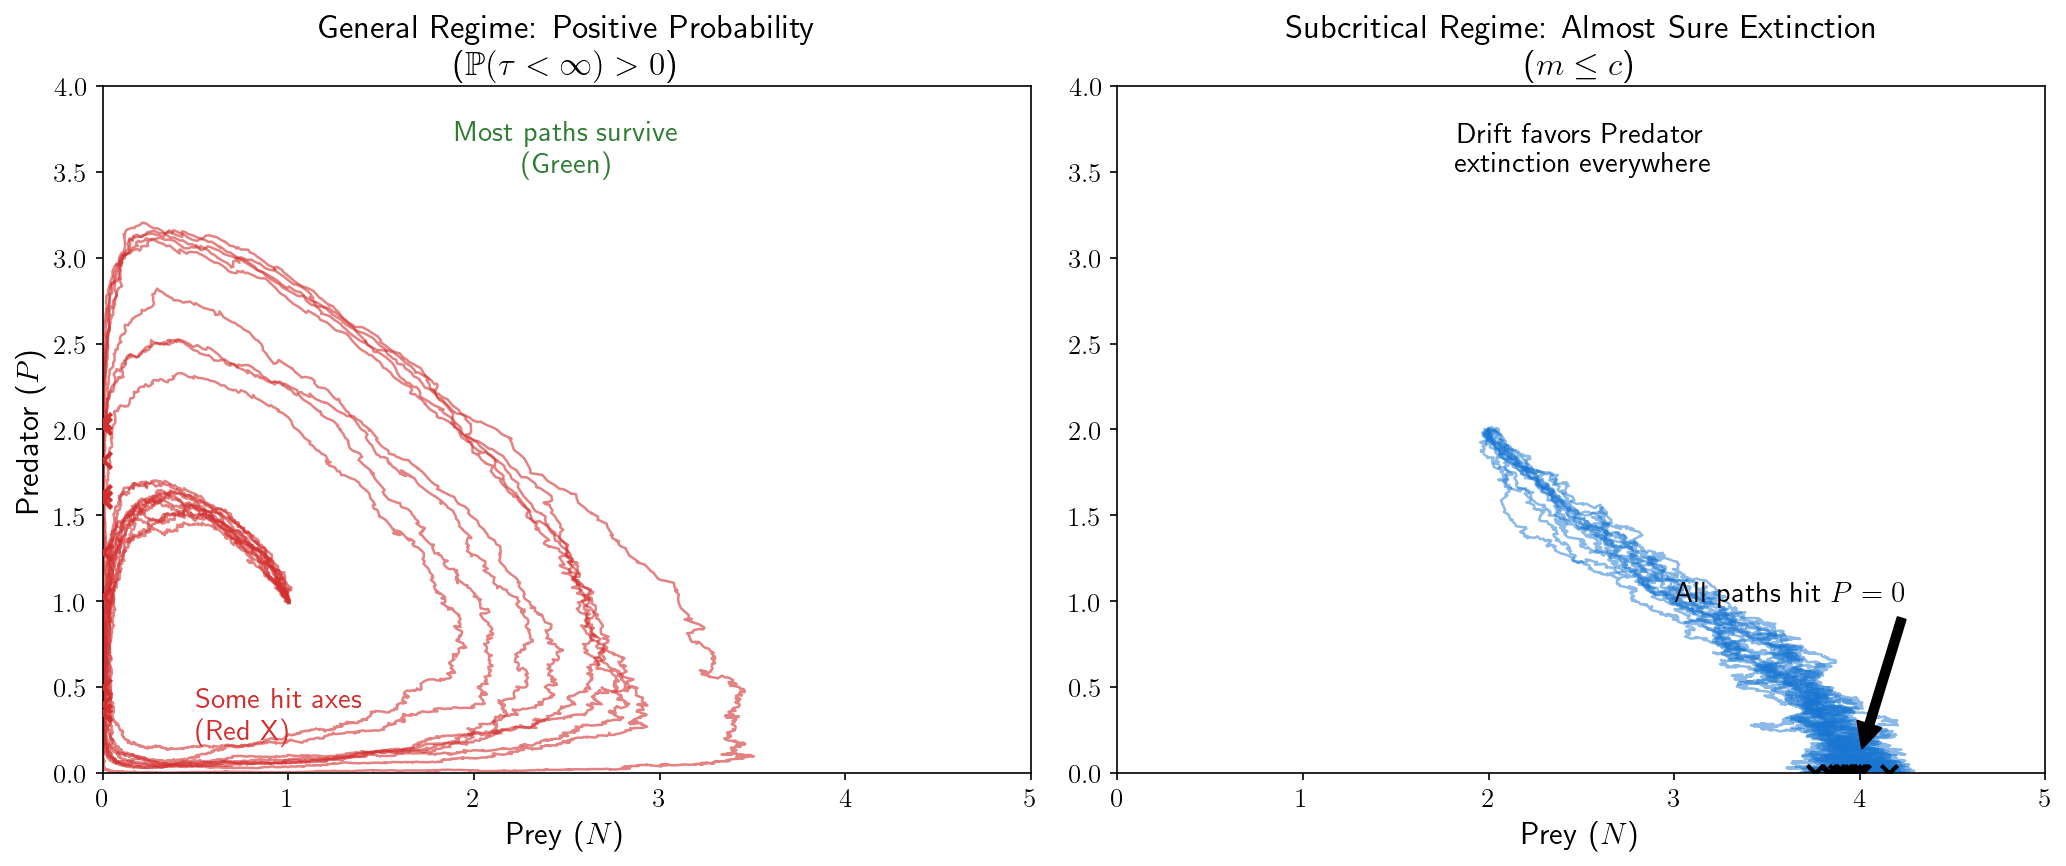

In [79]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from pathlib import Path

OUT_DIR = Path(r"C:\Users\lenovo\Downloads")
OUT_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'legend.title_fontsize': 12,
    'lines.linewidth': 2.0,
    'lines.markersize': 7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

def draw_extinction_scenarios():
    # --- SETUP ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Common simulation settings
    dt = 0.01
    T = 50
    steps = int(T/dt)
    n_paths = 12  # Number of stochastic paths to show
    omega = 300   # Noise level (moderate)
    rho = 1.0/np.sqrt(omega)
    
    # Helper: SDE Step
    def run_simulation(k, m, c, z0):
        N = np.zeros(steps)
        P = np.zeros(steps)
        N[0], P[0] = z0
        
        absorbed = False
        extinction_point = None
        
        for i in range(steps-1):
            n, p = N[i], P[i]
            
            # Check Absorption
            if n <= 0 or p <= 0:
                if not absorbed:
                    absorbed = True
                    extinction_point = (n, p)
                # Freeze
                N[i+1:] = n
                P[i+1:] = p
                break
            
            # Rates for noise
            r_birth = n
            r_comp = n**2/k
            r_death = c*p
            r_pred = (m*n*p)/(1+n)
            
            # Drift
            mu_n = n*(1 - n/k) - r_pred
            mu_p = r_pred - r_death
            
            # Noise (Simplified 2D Cholesky for speed/visuals)
            # Var(N) approx N + N^2/k + mNP/(1+N)
            # Var(P) approx cP + mNP/(1+N)
            # Cov(N,P) approx -mNP/(1+N)
            
            # We can use the explicit channel sum for accuracy
            dN_noise = (np.random.normal(0,1) * np.sqrt(r_birth) 
                        - np.random.normal(0,1) * np.sqrt(r_comp) 
                        - np.random.normal(0,1) * np.sqrt(r_pred))
            dP_noise = (-np.random.normal(0,1) * np.sqrt(r_death) 
                        + np.random.normal(0,1) * np.sqrt(r_pred)) # Correlated via r_pred source
            
            # But wait, to get the correlation right in simple code:
            # Let's just use the definition:
            # dW_B, dW_C, dW_D, dW_E independent
            dW = np.random.normal(0, np.sqrt(dt), 4)
            
            diff_N = (1*np.sqrt(r_birth)*dW[0] - 1*np.sqrt(r_comp)*dW[1] - 1*np.sqrt(r_pred)*dW[3])
            diff_P = (-1*np.sqrt(r_death)*dW[2] + 1*np.sqrt(r_pred)*dW[3])
            
            N[i+1] = n + mu_n*dt + rho*diff_N
            P[i+1] = p + mu_p*dt + rho*diff_P
            
        return N, P, extinction_point

    # --- PANEL 1: GENERAL REGIME (Theorem 6.3) ---
    ax1 = axes[0]
    # Parameters for Coexistence/Cycle
    k1, m1, c1 = 4.0, 2.0, 0.5 
    
    # Run multiple paths
    np.random.seed(10) # Seed where some go extinct, some don't
    extinct_count = 0
    
    for _ in range(n_paths):
        N, P, ext_pt = run_simulation(k1, m1, c1, z0=(1.0, 1.0))
        
        if ext_pt:
            # Plot extinct path
            ax1.plot(N, P, color='#D32F2F', alpha=0.6, lw=1.2)
            # Mark the hit
            x, y = ext_pt
            ax1.scatter(max(0, x), max(0, y), color='#D32F2F', marker='x', s=60, zorder=10)
            extinct_count += 1
        else:
            # Plot surviving path
            ax1.plot(N, P, color='#2E7D32', alpha=0.3, lw=1.0)

    ax1.set_title(f"General Regime: Positive Probability\n($\\mathbb{{P}}(\\tau < \\infty) > 0$)", fontweight='bold')
    ax1.set_xlabel('Prey ($N$)')
    ax1.set_ylabel('Predator ($P$)')
    ax1.set_xlim(0, 5)
    ax1.set_ylim(0, 4)
    
    # Annotation
    ax1.text(2.5, 3.5, "Most paths survive\n(Green)", color='#2E7D32', ha='center')
    ax1.text(0.5, 0.2, "Some hit axes\n(Red X)", color='#D32F2F', ha='left', fontweight='bold')

    # --- PANEL 2: SUBCRITICAL REGIME (Theorem 6.4) ---
    ax2 = axes[1]
    # Parameters where m <= c (Predator weak)
    k2 = 4.0
    m2 = 0.5 # Low predation efficiency
    c2 = 0.6 # High death rate
    # Condition m2 <= c2 holds (0.5 <= 0.6)
    
    for _ in range(n_paths):
        N, P, ext_pt = run_simulation(k2, m2, c2, z0=(2.0, 2.0))
        
        # All should be red/extinct
        ax2.plot(N, P, color='#1976D2', alpha=0.5, lw=1.2)
        if ext_pt:
             x, y = ext_pt
             ax2.scatter(max(0, x), max(0, y), color='black', marker='x', s=60, zorder=10)
    
    ax2.set_title(f"Subcritical Regime: Almost Sure Extinction\n($m \\leq c$)", fontweight='bold')
    ax2.set_xlabel('Prey ($N$)')
    ax2.set_xlim(0, 5)
    ax2.set_ylim(0, 4)
    
    # Nullcline visual for Subcritical
    # P-nullcline is N = c/(m-c). If m < c, it doesn't exist in positive quadrant.
    # So P drift is always negative.
    ax2.text(2.5, 3.5, "Drift favors Predator\nextinction everywhere", color='black', ha='center', style='italic')
    ax2.annotate("All paths hit $P=0$", xy=(4, 0.1), xytext=(3, 1.0),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontweight='bold')
    plt.tight_layout()
    outpath = OUT_DIR / 'Fig7.pdf'
    fig.savefig(outpath, bbox_inches='tight')
    print(f'Saved PDF to: {outpath}')
    plt.show()

if __name__ == "__main__":
    draw_extinction_scenarios()


Parameters: Params(k=3.0, m=2.0, c=0.8)
Regime summary:
Coexistence equilibrium exists: m > c and k > N*.
Diagnostic: k > k_H = 1 + 2N* = 2.333333 so trJ(K3) > 0; K3 is unstable.
Typical behavior: trajectories approach a stable limit cycle (sustained oscillations).

Equilibria:
  K0 = [0. 0.]
  K1 = [3. 0.]
  N* = 0.6666666666666667
  K3 = [0.66666667 0.64814815]
  k_H = 2.333333, trJ(K3) = 8.888889e-02
Saved PDF to: C:\Users\lenovo\Downloads\Fig8.pdf


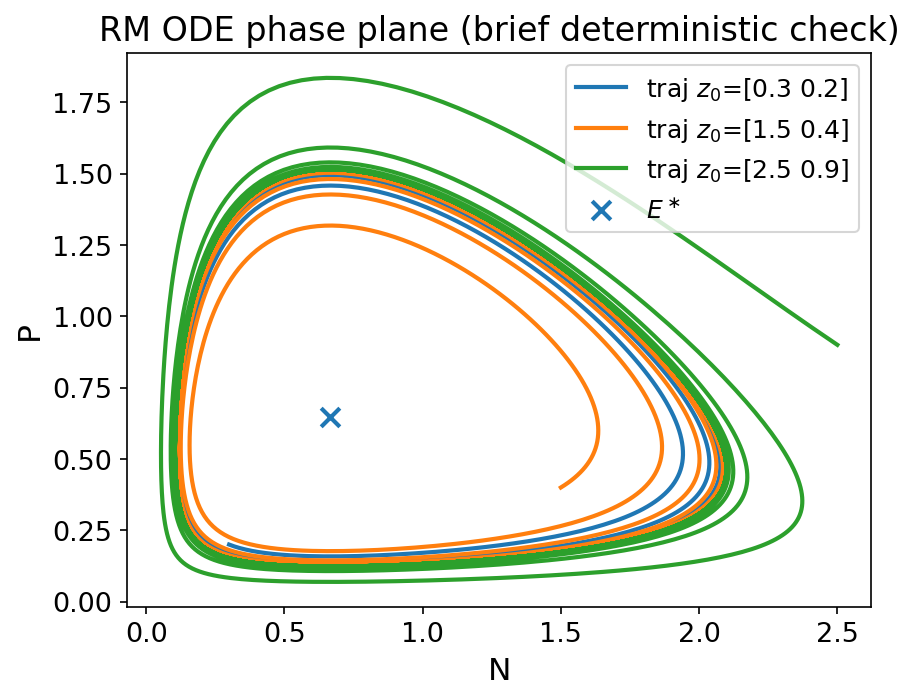


--- Extinction regime example (brief numeric check) ---
Parameters: Params(k=1.0, m=0.8, c=0.8)
Regime summary:
Deterministic predator extinction: m <= c.
Prediction: P(t) -> 0 and (for N0>0) N(t) -> k.
Terminal state at t=200.0: N=1.000000, P=0.000000 (expect P~0, N~k)


In [1]:
"""
Paper A — Section 8.1 Deterministic check (brief)
=================================================
This script provides a *minimal* deterministic check for the Rosenzweig–MacArthur (RM) ODE
that supports Paper A's narrative (parameter interpretation + boundedness intuition),
WITHOUT doing Hopf continuation or global planar dynamics proofs.

What it does:
1) Defines the RM ODE with Holling type II response.
2) Computes equilibria K0, K1, and (if it exists) coexistence equilibrium K3.
3) Reports deterministic extinction/coexistence thresholds:
   - Predator extinction if m <= c, or if m > c and k <= N* := c/(m-c) (including equality k=N*).
   - Coexistence equilibrium exists if m > c and k > N*.
4) (Optional but concise) Computes the Hopf threshold k_H = 1 + 2 N* and the Jacobian trace at K3:
   - If k < k_H, K3 is locally asymptotically stable (trace < 0, det > 0).
   - If k > k_H, K3 is unstable (trace > 0); trajectories typically approach a stable limit cycle.
   This is reported only as a *diagnostic* (no continuation; no proof).
5) Integrates a few trajectories and plots:
   - N(t) time series, P(t) time series
   - Phase plane with K3 marked (when it exists)

Dependencies:
- numpy
- scipy
- matplotlib
"""

from dataclasses import dataclass
from typing import Optional, Tuple, List
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

OUT_DIR = Path(r"C:\Users\lenovo\Downloads")
OUT_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'legend.title_fontsize': 12,
    'lines.linewidth': 2.0,
    'lines.markersize': 7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})


# -------------------------
# Model and utilities
# -------------------------
@dataclass(frozen=True)
class Params:
    k: float
    m: float
    c: float


def rm_rhs(t: float, z: np.ndarray, par: Params) -> np.ndarray:
    """RM ODE with Holling type II functional response."""
    N, P = z
    k, m, c = par.k, par.m, par.c
    dN = N * (1.0 - N / k) - (m * N * P) / (1.0 + N)
    dP = P * ((m * N) / (1.0 + N) - c)
    return np.array([dN, dP], dtype=float)


def compute_equilibria(par: Params) -> Tuple[np.ndarray, np.ndarray, Optional[np.ndarray], Optional[float]]:
    """
    Return equilibria K0, K1, K3 (if exists), and N* (if m>c).
    K0 = (0,0), K1 = (k,0).
    K3 exists iff m>c and N*<k.
    """
    k, m, c = par.k, par.m, par.c
    K0 = np.array([0.0, 0.0])
    K1 = np.array([k, 0.0])

    if m <= c:
        return K0, K1, None, None

    N_star = c / (m - c)
    if N_star < k:
        P_star = (1.0 + N_star) / m * (1.0 - N_star / k)
        K3 = np.array([N_star, P_star], dtype=float)
        return K0, K1, K3, N_star

    # includes equality N_star == k (threshold): no positive equilibrium
    return K0, K1, None, N_star


def hopf_threshold(N_star: float) -> float:
    """Hopf threshold k_H = 1 + 2 N* (valid in coexistence regime)."""
    return 1.0 + 2.0 * N_star


def trace_at_K3(par: Params, N_star: float) -> float:
    """
    Trace of Jacobian at K3 simplifies to:
    tr J(K3) = (N*/(1+N*)) * (1 - (1+2N*)/k)
    """
    k = par.k
    return (N_star / (1.0 + N_star)) * (1.0 - (1.0 + 2.0 * N_star) / k)


def classify_regime(par: Params) -> str:
    """
    Paper A relevant deterministic classification:
    - Extinction region(s) for predator
    - Coexistence equilibrium existence
    Plus (brief diagnostic) local stability of K3 via k vs k_H when K3 exists.
    """
    k, m, c = par.k, par.m, par.c

    # Predator subcritical
    if m <= c:
        return (
            "Deterministic predator extinction: m <= c.\n"
            "Prediction: P(t) -> 0 and (for N0>0) N(t) -> k."
        )

    # m > c
    N_star = c / (m - c)

    if k < N_star:
        return (
            "Deterministic predator extinction: m > c but k < N* = c/(m-c).\n"
            "Prediction: P(t) -> 0 and (for N0>0) N(t) -> k."
        )

    if np.isclose(k, N_star):
        return (
            "Threshold equality: m > c and k = N*.\n"
            "Prediction (still): P(t) -> 0 and (for N0>0) N(t) -> k; no positive equilibrium."
        )

    # Coexistence equilibrium exists
    kH = hopf_threshold(N_star)
    tr = trace_at_K3(par, N_star)
    # det>0 in coexistence region; sign of trace determines local stability type
    if k < kH:
        return (
            "Coexistence equilibrium exists: m > c and k > N*.\n"
            f"Diagnostic: k < k_H = 1 + 2N* = {kH:.6f} so trJ(K3) < 0; K3 is locally asymptotically stable.\n"
            "Typical behavior: trajectories approach K3."
        )
    if np.isclose(k, kH):
        return (
            "Coexistence equilibrium exists: m > c and k > N*.\n"
            f"Diagnostic: k ≈ k_H = 1 + 2N* = {kH:.6f} so trJ(K3) ≈ 0; Hopf threshold (degenerate for numerics).\n"
            "Typical behavior: near-threshold long transients; small oscillations may appear."
        )
    return (
        "Coexistence equilibrium exists: m > c and k > N*.\n"
        f"Diagnostic: k > k_H = 1 + 2N* = {kH:.6f} so trJ(K3) > 0; K3 is unstable.\n"
        "Typical behavior: trajectories approach a stable limit cycle (sustained oscillations)."
    )


def simulate_ode(
    par: Params,
    z0: np.ndarray,
    T: float = 250.0,
    dt: float = 0.05,
    rtol: float = 1e-9,
    atol: float = 1e-12,
) -> Tuple[np.ndarray, np.ndarray]:
    """Integrate RM ODE and return (t_grid, z(t_grid))."""
    z0 = np.maximum(z0.astype(float), 0.0)  # enforce nonnegative start
    t_eval = np.arange(0.0, T + dt, dt)

    sol = solve_ivp(
        fun=lambda t, z: rm_rhs(t, z, par),
        t_span=(0.0, T),
        y0=z0,
        t_eval=t_eval,
        method="RK45",
        rtol=rtol,
        atol=atol,
        max_step=0.5,
    )
    if not sol.success:
        raise RuntimeError(f"ODE solver failed: {sol.message}")

    return sol.t, sol.y  # y shape = (2, len(t))


# -------------------------
# Plotting
# -------------------------
def plot_deterministic_check(
    par: Params,
    initials: List[np.ndarray],
    T: float = 250.0,
    dt: float = 0.05,
    show: bool = True,
    save_prefix: Optional[str] = None,
):
    """
    Produce 3 plots:
    1) Prey time series
    2) Predator time series
    3) Phase plane
    Optionally save figures as PDF with the given prefix.
    """
    # Regime + equilibria
    print("\nParameters:", par)
    print("Regime summary:\n" + classify_regime(par))

    K0, K1, K3, N_star = compute_equilibria(par)
    print("\nEquilibria:")
    print("  K0 =", K0)
    print("  K1 =", K1)
    if N_star is not None:
        print("  N* =", N_star)
    if K3 is not None:
        print("  K3 =", K3)
        kH = hopf_threshold(N_star)
        tr = trace_at_K3(par, N_star)
        print(f"  k_H = {kH:.6f}, trJ(K3) = {tr:.6e}")
    else:
        print("  K3 does not exist (no positive equilibrium).")

    # --- Phase plane ---
    fig3 = plt.figure()
    for z0 in initials:
        t, y = simulate_ode(par, z0, T=T, dt=dt)
        plt.plot(y[0, :], y[1, :], label=f"traj $z_0$={np.array(z0)}")
    if K3 is not None:
        plt.scatter([K3[0]], [K3[1]], marker="x", s=80, label=r"$E^\ast$")
    plt.xlabel("N")
    plt.ylabel("P")
    plt.title("RM ODE phase plane (brief deterministic check)")
    plt.legend()

    # Save if requested
    if save_prefix is not None:
        save_prefix_path = Path(str(save_prefix))
        save_prefix_path.parent.mkdir(parents=True, exist_ok=True)
        outpath = OUT_DIR / 'Fig8.pdf'
        fig3.savefig(outpath, bbox_inches='tight')
        print(f'Saved PDF to: {outpath}')
        plt.show()


# -------------------------
# Main
# -------------------------
def main():
    # Example A (coexistence + oscillations): k > k_H
    par1 = Params(k=3.0, m=2.0, c=0.8)
    initials1 = [np.array([0.3, 0.2]), np.array([1.5, 0.4]), np.array([2.5, 0.9])]
    plot_deterministic_check(par1, initials1, T=250.0, dt=0.05, show=True, save_prefix=str(OUT_DIR / 'fig_deterministic_check'))

    # Example B (subcritical extinction): m <= c
    par2 = Params(k=1.0, m=0.8, c=0.8)
    initials2 = [np.array([0.5, 0.6])]
    # For extinction case, just do a short run and print terminal values.
    print("\n--- Extinction regime example (brief numeric check) ---")
    print("Parameters:", par2)
    print("Regime summary:\n" + classify_regime(par2))
    t, y = simulate_ode(par2, initials2[0], T=200.0, dt=0.05)
    print(f"Terminal state at t={t[-1]:.1f}: N={y[0,-1]:.6f}, P={y[1,-1]:.6f} (expect P~0, N~k)")

if __name__ == "__main__":
    main()

Single path (chol): tau_dt = 87.78
Saved PDF to: C:\Users\lenovo\Downloads\Fig9a.pdf


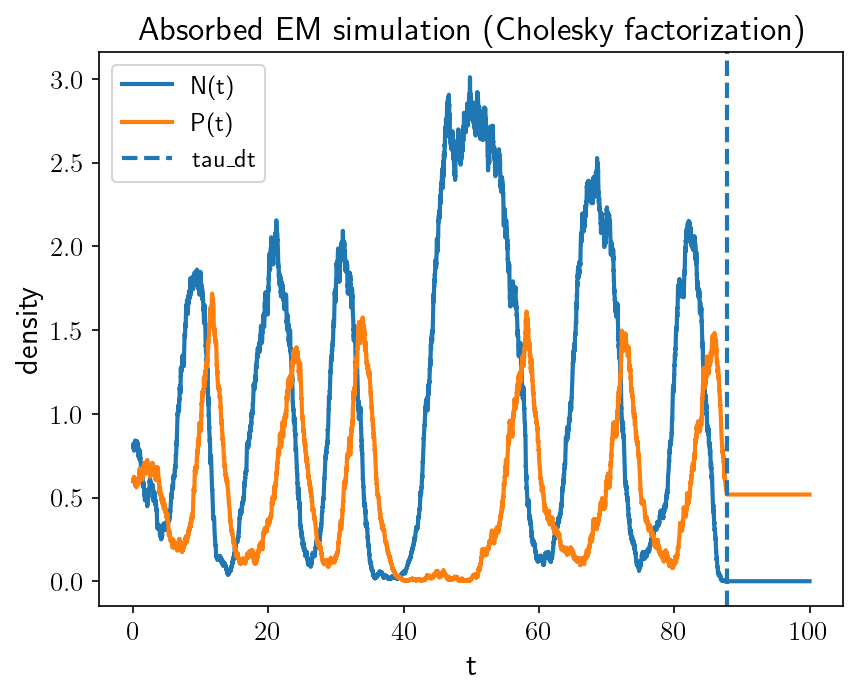

Saved PDF to: C:\Users\lenovo\Downloads\Fig9b.pdf


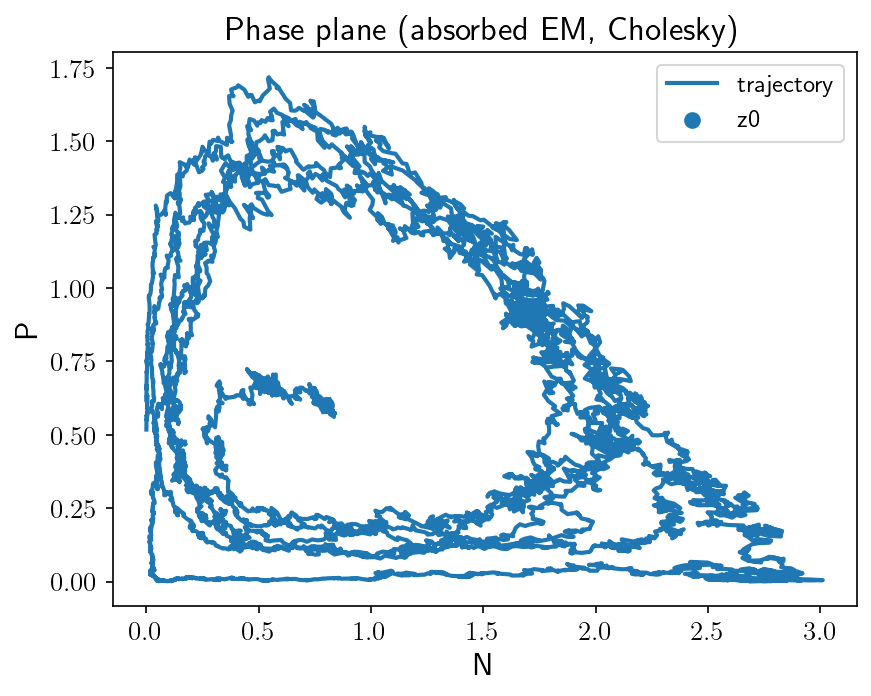

Single path (event): tau_dt = 51.31
Saved PDF to: C:\Users\lenovo\Downloads\Fig9c.pdf


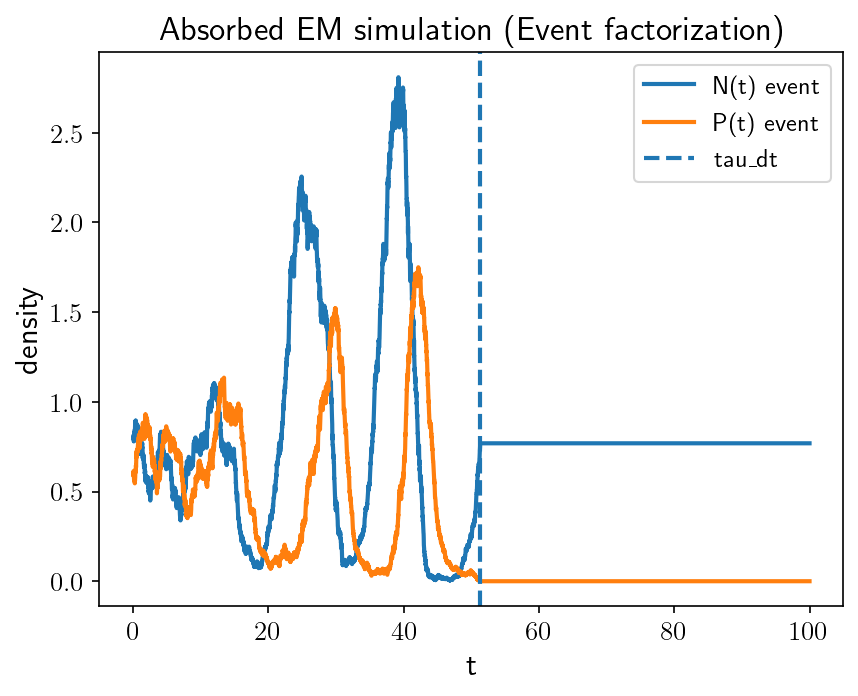

Saved PDF to: C:\Users\lenovo\Downloads\Fig10.pdf


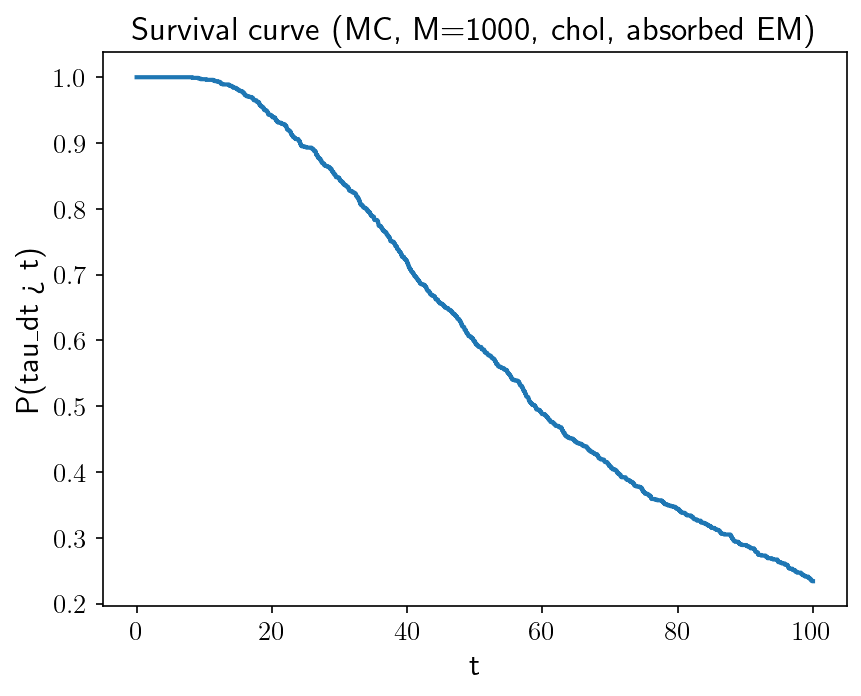

In [ ]:
"""
Paper A — Section 8.2
Stochastic simulation of the absorbed mechanistic diffusion (Euler–Maruyama + clipping/freezing)

Implements:
- Drift mu(N,P) from eq. (mu_explicit_A)
- Event factorization L_ev (2x4) from eq. (Levent_explicit_A)
- Cholesky factor L_chol (2x2) from eq. (Cholesky_explicit_A)
- Euler–Maruyama scheme
- Absorption convention: clipping to 0 at first nonpositive coordinate, then freezing thereafter

Outputs:
- Example path plots (time series + phase plane)
- Optional Monte Carlo survival curve P(tau > t)

Dependencies: numpy, matplotlib
"""

from dataclasses import dataclass
from typing import Literal, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

OUT_DIR = Path(r"C:\Users\lenovo\Downloads")
OUT_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'legend.title_fontsize': 12,
    'lines.linewidth': 2.0,
    'lines.markersize': 7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})


@dataclass(frozen=True)
class Params:
    k: float
    m: float
    c: float


def mu(z: np.ndarray, par: Params) -> np.ndarray:
    """Drift mu(N,P) = ( N - N^2/k - mNP/(1+N),  mNP/(1+N) - cP )."""
    N, P = z
    k, m, c = par.k, par.m, par.c
    denom = 1.0 + N
    return np.array(
        [
            N - (N * N) / k - (m * N * P) / denom,
            (m * N * P) / denom - c * P,
        ],
        dtype=float,
    )


def sigma_entries(z: np.ndarray, par: Params) -> Tuple[float, float, float]:
    """
    Return (Sigma11, Sigma12, Sigma22) for Sigma(N,P) in eq. (Sigma_explicit_A):
      Sigma11 = N + N^2/k + mNP/(1+N)
      Sigma12 = - mNP/(1+N)
      Sigma22 = cP + mNP/(1+N)
    """
    N, P = z
    k, m, c = par.k, par.m, par.c
    denom = 1.0 + N
    a = (m * N * P) / denom
    s11 = N + (N * N) / k + a
    s12 = -a
    s22 = c * P + a
    return float(s11), float(s12), float(s22)


def L_event(z: np.ndarray, par: Params) -> np.ndarray:
    """
    Event factorization L_ev (2x4) from eq. (Levent_explicit_A):
      columns correspond to B, C, D, E.
    """
    N, P = z
    k, m, c = par.k, par.m, par.c

    # Rates (density-level)
    lam_B = max(N, 0.0)
    lam_C = max((N * N) / k, 0.0)
    lam_D = max(c * P, 0.0)
    lam_E = max((m * N * P) / (1.0 + N), 0.0)

    L = np.zeros((2, 4), dtype=float)
    # Column B: sqrt(lam_B) * (1,0)
    L[:, 0] = [np.sqrt(lam_B), 0.0]
    # Column C: sqrt(lam_C) * (-1,0)
    L[:, 1] = [-np.sqrt(lam_C), 0.0]
    # Column D: sqrt(lam_D) * (0,-1)
    L[:, 2] = [0.0, -np.sqrt(lam_D)]
    # Column E: sqrt(lam_E) * (-1,1)
    s = np.sqrt(lam_E)
    L[:, 3] = [-s, s]
    return L


def L_cholesky(z: np.ndarray, par: Params) -> np.ndarray:
    """
    Cholesky factor L_chol (2x2) for Sigma on the interior U.
    For numerical stability, this handles small roundoff and clips the second diagonal term at 0.
    """
    s11, s12, s22 = sigma_entries(z, par)
    if s11 <= 0.0:
        # Degenerate case (on boundary); return zeros
        return np.zeros((2, 2), dtype=float)

    L = np.zeros((2, 2), dtype=float)
    L[0, 0] = np.sqrt(s11)
    L[1, 0] = s12 / L[0, 0]
    # Schur complement
    schur = s22 - (s12 * s12) / s11
    L[1, 1] = np.sqrt(max(schur, 0.0))
    return L


def em_absorbed_path(
    par: Params,
    z0: np.ndarray,
    rho: float = 0.1,
    dt: float = 1e-2,
    T: float = 50.0,
    factor: Literal["event", "chol"] = "chol",
    seed: Optional[int] = None,
) -> Tuple[np.ndarray, np.ndarray, float]:
    """
    Simulate one absorbed EM path.

    Absorption (clipping+freezing):
    - If after update N<=0 or P<=0: clip to 0 componentwise and mark absorbed.
    - Thereafter: keep state constant.

    Returns:
      t_grid: shape (n_steps+1,)
      Z: shape (n_steps+1, 2)
      tau_dt: discrete absorption time (np.inf if not absorbed by T)
    """
    rng = np.random.default_rng(seed)
    z0 = np.array(z0, dtype=float)
    if np.any(z0 <= 0.0):
        raise ValueError("Initial condition must be in U=(0,∞)^2 for this simulator.")

    n_steps = int(np.floor(T / dt))
    t = np.linspace(0.0, n_steps * dt, n_steps + 1)
    Z = np.zeros((n_steps + 1, 2), dtype=float)
    Z[0] = z0

    # driving dimension
    d = 4 if factor == "event" else 2
    sqrt_dt = np.sqrt(dt)

    absorbed = False
    tau_dt = np.inf

    for n in range(n_steps):
        if absorbed:
            Z[n + 1] = Z[n]  # freezing
            continue

        z = Z[n]
        drift = mu(z, par)

        if factor == "event":
            L = L_event(z, par)
        else:
            L = L_cholesky(z, par)

        dB = rng.standard_normal(d) * sqrt_dt
        # diffusion increment: (2xd) @ (d,)
        diff_inc = rho * (L @ dB)

        z_next = z + drift * dt + diff_inc

        # absorption test: if any coordinate <= 0, clip to 0 and freeze thereafter
        if (z_next[0] <= 0.0) or (z_next[1] <= 0.0):
            z_next = np.maximum(z_next, 0.0)  # clipping
            absorbed = True
            tau_dt = (n + 1) * dt

        Z[n + 1] = z_next

    return t, Z, tau_dt


def survival_curve_mc(
    par: Params,
    z0: np.ndarray,
    rho: float = 0.1,
    dt: float = 1e-2,
    T: float = 50.0,
    M: int = 2000,
    factor: Literal["event", "chol"] = "chol",
    seed: int = 0,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Monte Carlo estimate of survival curve t -> P(tau_dt > t).

    Returns:
      t_grid: shape (n_steps+1,)
      surv:  shape (n_steps+1,)
    """
    rng = np.random.default_rng(seed)
    n_steps = int(np.floor(T / dt))
    t_grid = np.linspace(0.0, n_steps * dt, n_steps + 1)

    taus = np.empty(M, dtype=float)
    for i in range(M):
        _, _, tau_dt = em_absorbed_path(
            par,
            z0=z0,
            rho=rho,
            dt=dt,
            T=T,
            factor=factor,
            seed=int(rng.integers(0, 2**31 - 1)),
        )
        taus[i] = tau_dt

    surv = np.array([(taus > t).mean() for t in t_grid], dtype=float)
    return t_grid, surv


def main():
    # Example parameters (same as earlier deterministic check)
    par = Params(k=3.0, m=2.0, c=0.8)
    rho = 0.1         # Omega=100
    dt = 0.01
    T = 100.0
    z0 = np.array([0.8, 0.6])  # interior start

    # --- Single path (Cholesky) ---
    t, Z, tau_dt = em_absorbed_path(par, z0, rho=rho, dt=dt, T=T, factor="chol", seed=1)
    print(f"Single path (chol): tau_Δt = {tau_dt}")

    plt.figure()
    plt.plot(t, Z[:, 0], label="N(t)")
    plt.plot(t, Z[:, 1], label="P(t)")
    plt.axvline(tau_dt, linestyle="--", label=r"$\tau_{\Delta t}$" if np.isfinite(tau_dt) else None)
    plt.xlabel("t")
    plt.ylabel("density")
    plt.title("Absorbed EM simulation (Cholesky factorization)")
    plt.legend()
    outpath = OUT_DIR / 'Fig9a.pdf'
    fig=plt.gcf()
    fig.savefig(outpath, bbox_inches='tight')
    print(f'Saved PDF to: {outpath}')
    plt.show()


    plt.figure()
    plt.plot(Z[:, 0], Z[:, 1], label="trajectory")
    plt.scatter([z0[0]], [z0[1]], marker="o", label="z0")
    plt.xlabel("N")
    plt.ylabel("P")
    plt.title("Phase plane (absorbed EM, Cholesky)")
    plt.legend()
    outpath = OUT_DIR / 'Fig9b.pdf'
    fig = plt.gcf()
    fig.savefig(outpath, bbox_inches='tight')
    print(f'Saved PDF to: {outpath}')
    plt.show()

    # --- Single path (Event factorization) ---
    t2, Z2, tau_dt2 = em_absorbed_path(par, z0, rho=rho, dt=dt, T=T, factor="event", seed=1)
    print(f"Single path (event): tau_dt = {tau_dt2}")

    plt.figure()
    plt.plot(t2, Z2[:, 0], label="N(t) event")
    plt.plot(t2, Z2[:, 1], label="P(t) event")
    plt.axvline(tau_dt2, linestyle="--", label="tau_dt" if np.isfinite(tau_dt2) else None)
    plt.xlabel("t")
    plt.ylabel("density")
    plt.title("Absorbed EM simulation (Event factorization)")
    plt.legend()
    outpath = OUT_DIR / 'Fig9c.pdf'
    fig=plt.gcf()
    fig.savefig(outpath, bbox_inches='tight')
    print(f'Saved PDF to: {outpath}')
    plt.show()

    M = 1000
    tS, surv = survival_curve_mc(par, z0, rho=rho, dt=dt, T=T, M=M, factor="chol", seed=123)
    plt.figure()
    plt.plot(tS, surv)
    plt.xlabel("t")
    plt.ylabel(r"$\mathbb{P}(\tau_{\Delta t} > t)$")
    plt.title(f"Survival curve (MC, M={M}, chol, absorbed EM)")
    outpath = OUT_DIR / 'Fig10.pdf'
    fig=plt.gcf()
    fig.savefig(outpath, bbox_inches='tight')
    print(f'Saved PDF to: {outpath}')
    plt.show()
    plt.show()


if __name__ == "__main__":
    main()

Running factorization-consistency Monte Carlo...
Params=Params(k=3.0, m=2.0, c=0.8), rho=0.1, dt=0.01, T=100.0, z0=[0.8, 0.6], M=2000
Event:  survivor_frac@T=100.0  = 0.244
Chol:   survivor_frac@T=100.0  = 0.245
Saved figure to: fig_sde_consistency.png


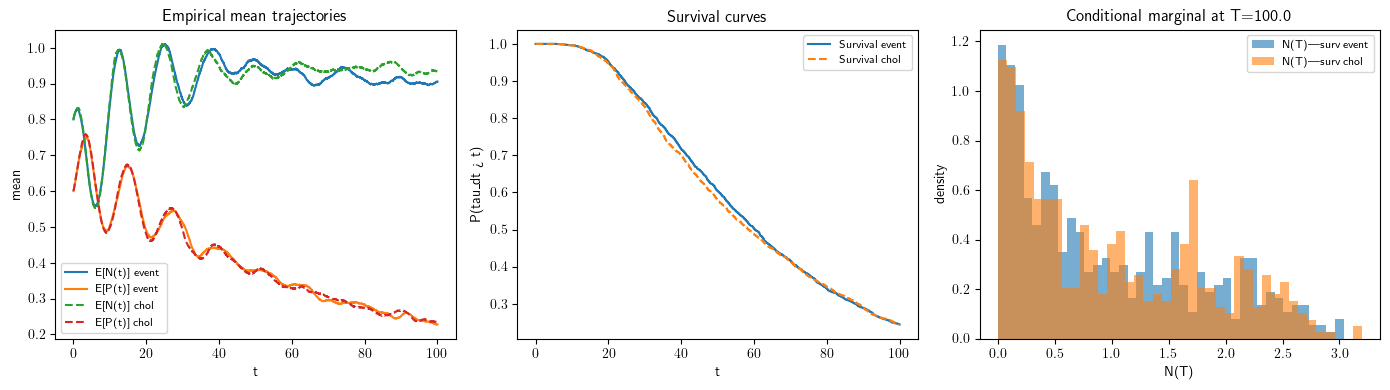

In [64]:
"""
Paper A — Section 8.3
Factorization consistency: event vs Cholesky (finite-sample diagnostics)

Goal:
Compare two equivalent factorizations of the same covariance Sigma(N,P):
  (i)  Event factorization  L_ev  (2x4)
  (ii) Cholesky factor      L_chol (2x2)
Both satisfy L L^T = Sigma on the interior U, hence define the same diffusion in continuous time.

We compare under absorbed Euler–Maruyama (EM) discretization (clipping + freezing at axes):
  (1) Unconditional mean trajectories E[N(t)], E[P(t)]
  (2) Survival curves  t -> P(tau_dt > t)
  (3) Conditional marginal of N(T) given survival (tau_dt > T)

Outputs:
- A 1x3 figure: mean trajectories (N,P), survival curves, conditional marginal histogram
- Optionally saves as fig_sde_consistency.png

Dependencies: numpy, matplotlib
"""

from dataclasses import dataclass
from typing import Literal, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

OUT_DIR = Path(r"C:\Users\lenovo\Downloads")
OUT_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'legend.title_fontsize': 12,
    'lines.linewidth': 2.0,
    'lines.markersize': 7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})


@dataclass(frozen=True)
class Params:
    k: float
    m: float
    c: float


# --------------------------
# Model: mu, Sigma, factors
# --------------------------
def mu(z: np.ndarray, par: Params) -> np.ndarray:
    N, P = z
    k, m, c = par.k, par.m, par.c
    denom = 1.0 + N
    return np.array(
        [
            N - (N * N) / k - (m * N * P) / denom,
            (m * N * P) / denom - c * P,
        ],
        dtype=float,
    )


def sigma_entries(z: np.ndarray, par: Params) -> Tuple[float, float, float]:
    N, P = z
    k, m, c = par.k, par.m, par.c
    denom = 1.0 + N
    a = (m * N * P) / denom
    s11 = N + (N * N) / k + a
    s12 = -a
    s22 = c * P + a
    return float(s11), float(s12), float(s22)


def L_event(z: np.ndarray, par: Params) -> np.ndarray:
    """
    L_ev (2x4):
      columns correspond to events B, C, D, E.
    """
    N, P = z
    k, m, c = par.k, par.m, par.c

    lam_B = max(N, 0.0)
    lam_C = max((N * N) / k, 0.0)
    lam_D = max(c * P, 0.0)
    lam_E = max((m * N * P) / (1.0 + N), 0.0)

    L = np.zeros((2, 4), dtype=float)
    L[:, 0] = [np.sqrt(lam_B), 0.0]
    L[:, 1] = [-np.sqrt(lam_C), 0.0]
    L[:, 2] = [0.0, -np.sqrt(lam_D)]
    s = np.sqrt(lam_E)
    L[:, 3] = [-s, s]
    return L


def L_cholesky(z: np.ndarray, par: Params) -> np.ndarray:
    """Lower-triangular Cholesky factor (2x2) for Sigma on interior U; robustified for roundoff."""
    s11, s12, s22 = sigma_entries(z, par)
    if s11 <= 0.0:
        return np.zeros((2, 2), dtype=float)

    L = np.zeros((2, 2), dtype=float)
    L[0, 0] = np.sqrt(s11)
    L[1, 0] = s12 / L[0, 0]
    schur = s22 - (s12 * s12) / s11
    L[1, 1] = np.sqrt(max(schur, 0.0))
    return L


# --------------------------
# Absorbed EM simulator
# --------------------------
def em_absorbed_paths(
    par: Params,
    z0: np.ndarray,
    rho: float,
    dt: float,
    T: float,
    M: int,
    factor: Literal["event", "chol"] = "chol",
    seed: int = 0,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Simulate M absorbed EM paths.

    Absorption (clipping+freezing):
      - If N or P becomes <=0 after an update: clip to 0 and mark absorbed.
      - After absorption: freeze at boundary point.

    Returns:
      t_grid: shape (n_steps+1,)
      Z: shape (M, n_steps+1, 2)
      tau_dt: shape (M,), absorption times (np.inf if not absorbed by T)
    """
    rng = np.random.default_rng(seed)
    z0 = np.array(z0, dtype=float)
    if np.any(z0 <= 0.0):
        raise ValueError("z0 must be in U=(0,∞)^2")

    n_steps = int(np.floor(T / dt))
    t_grid = np.linspace(0.0, n_steps * dt, n_steps + 1)

    Z = np.zeros((M, n_steps + 1, 2), dtype=float)
    Z[:, 0, :] = z0[None, :]
    tau_dt = np.full(M, np.inf, dtype=float)

    d = 4 if factor == "event" else 2
    sqrt_dt = np.sqrt(dt)

    # Pre-generate Gaussian increments for speed: (M, n_steps, d)
    dB = rng.standard_normal((M, n_steps, d)) * sqrt_dt

    absorbed = np.zeros(M, dtype=bool)

    for n in range(n_steps):
        # update only non-absorbed
        idx = np.where(~absorbed)[0]
        if idx.size == 0:
            # all absorbed; just freeze forward
            Z[:, n + 1, :] = Z[:, n, :]
            continue

        # freeze absorbed ones
        Z[absorbed, n + 1, :] = Z[absorbed, n, :]

        # update active ones
        for i in idx:
            z = Z[i, n, :]
            drift = mu(z, par)

            if factor == "event":
                L = L_event(z, par)
            else:
                L = L_cholesky(z, par)

            z_next = z + drift * dt + rho * (L @ dB[i, n, :])

            # absorption trigger
            if (z_next[0] <= 0.0) or (z_next[1] <= 0.0):
                z_next = np.maximum(z_next, 0.0)  # clipping
                absorbed[i] = True
                tau_dt[i] = (n + 1) * dt

            Z[i, n + 1, :] = z_next

    return t_grid, Z, tau_dt


# --------------------------
# Diagnostics + plotting
# --------------------------
def compute_diagnostics(t: np.ndarray, Z: np.ndarray, tau_dt: np.ndarray) -> dict:
    """
    Given trajectories Z (M, T, 2) and tau_dt (M,), compute:
      - mean_N(t), mean_P(t)
      - survival(t) = P(tau_dt > t)
      - conditional sample of N(T) given survival
    """
    mean_N = Z[:, :, 0].mean(axis=0)
    mean_P = Z[:, :, 1].mean(axis=0)
    survival = np.array([(tau_dt > tt).mean() for tt in t], dtype=float)

    T_final = t[-1]
    survivors = tau_dt > T_final
    N_T_surv = Z[survivors, -1, 0] if np.any(survivors) else np.array([], dtype=float)

    return {
        "mean_N": mean_N,
        "mean_P": mean_P,
        "survival": survival,
        "N_T_surv": N_T_surv,
        "survivor_frac": float(survivors.mean()),
        "T_final": float(T_final),
    }


def plot_consistency_figure(
    t: np.ndarray,
    diag_ev: dict,
    diag_ch: dict,
    bins: int = 40,
    savepath: Optional[str] = "fig_sde_consistency.png",
    show: bool = True,
):
    """
    Create a 1x3 figure:
      Left: mean trajectories (N and P) for both methods
      Center: survival curves
      Right: conditional marginal of N(T) given survival
    """
    fig = plt.figure(figsize=(14, 4))

    # (1) mean trajectories
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.plot(t, diag_ev["mean_N"], label="E[N(t)] event")
    ax1.plot(t, diag_ev["mean_P"], label="E[P(t)] event")
    ax1.plot(t, diag_ch["mean_N"], linestyle="--", label="E[N(t)] chol")
    ax1.plot(t, diag_ch["mean_P"], linestyle="--", label="E[P(t)] chol")
    ax1.set_xlabel("t")
    ax1.set_ylabel("mean")
    ax1.set_title("Empirical mean trajectories")

    # (2) survival curves
    ax2 = fig.add_subplot(1, 3, 2)
    ax2.plot(t, diag_ev["survival"], label="Survival event")
    ax2.plot(t, diag_ch["survival"], linestyle="--", label="Survival chol")
    ax2.set_xlabel("t")
    ax2.set_ylabel("P(tau_dt > t)")
    ax2.set_title("Survival curves")

    # (3) conditional marginal N(T) | survival
    ax3 = fig.add_subplot(1, 3, 3)
    if diag_ev["N_T_surv"].size > 0:
        ax3.hist(diag_ev["N_T_surv"], bins=bins, density=True, alpha=0.6, label="N(T)|surv event")
    if diag_ch["N_T_surv"].size > 0:
        ax3.hist(diag_ch["N_T_surv"], bins=bins, density=True, alpha=0.6, label="N(T)|surv chol")
    ax3.set_xlabel("N(T)")
    ax3.set_ylabel("density")
    ax3.set_title(f"Conditional marginal at T={diag_ev['T_final']:.1f}")

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")
        print(f"Saved figure to: {savepath}")

    if show:
        plt.show()
    else:
        plt.close(fig)


def main():
    # Parameters consistent with Paper A numerics narrative
    par = Params(k=3.0, m=2.0, c=0.8)
    rho = 0.1          # Omega=100
    dt = 1e-2
    T = 100.0
    z0 = np.array([0.8, 0.6])
    M = 2000

    print("Running factorization-consistency Monte Carlo...")
    print(f"Params={par}, rho={rho}, dt={dt}, T={T}, z0={z0.tolist()}, M={M}")

    # Event factorization
    t, Z_ev, tau_ev = em_absorbed_paths(par, z0, rho, dt, T, M, factor="event", seed=123)
    diag_ev = compute_diagnostics(t, Z_ev, tau_ev)
    print(f"Event:  survivor_frac@T={diag_ev['T_final']:.1f}  = {diag_ev['survivor_frac']:.3f}")

    # Cholesky factorization
    t, Z_ch, tau_ch = em_absorbed_paths(par, z0, rho, dt, T, M, factor="chol", seed=456)
    diag_ch = compute_diagnostics(t, Z_ch, tau_ch)
    print(f"Chol:   survivor_frac@T={diag_ch['T_final']:.1f}  = {diag_ch['survivor_frac']:.3f}")

    # Plot comparison
    plot_consistency_figure(
        t=t,
        diag_ev=diag_ev,
        diag_ch=diag_ch,
        bins=40,
        savepath="fig_sde_consistency.png",
        show=True,
    )


if __name__ == "__main__":
    main()

Running covariance-role comparison (full vs diagonal surrogate)...
Params=Params(k=3.0, m=2.0, c=0.8), rho=0.1, dt=0.01, T=100.0, z0=[0.8, 0.6], M=100
Full Σ: survivor_frac@T=100.0 = 0.320
Diag Σ: survivor_frac@T=100.0 = 0.150
Saved figure to: fig_covariance_role.png


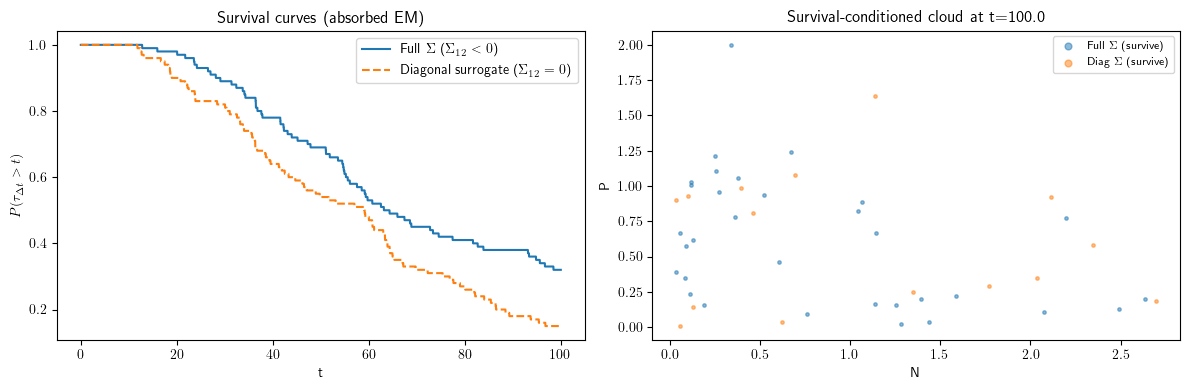

In [68]:
"""
Paper A — Section 8.4
Role of covariance: full Sigma vs diagonal surrogate (matched marginal variances)

We compare:
  FULL model:    dZ = mu(Z) dt + rho * L_chol(Z) dB,  where L_chol L_chol^T = Sigma (with Sigma12<0)
  DIAG surrogate dZ = mu(Z) dt + rho * L_diag(Z) dB,  where L_diag L_diag^T = Sigma_diag = diag(Sigma11,Sigma22)

Both use the same drift mu. The diagonal surrogate removes instantaneous correlation while preserving pointwise
marginal variances.

Numerics:
- Absorbed Euler–Maruyama with clipping+freezing at axes
- Diagnostics:
  (i) Survival curves t -> P(tau_dt > t)
  (ii) Snapshot of survival-conditioned particle cloud at time T_snap (phase plane)
- Saves a figure fig_covariance_role.png with two panels (survival curves, snapshot cloud)

Dependencies: numpy, matplotlib
"""

from dataclasses import dataclass
from typing import Tuple, Optional, Literal
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

OUT_DIR = Path(r"C:\Users\lenovo\Downloads")
OUT_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'legend.title_fontsize': 12,
    'lines.linewidth': 2.0,
    'lines.markersize': 7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})


@dataclass(frozen=True)
class Params:
    k: float
    m: float
    c: float


# --------------------------
# Drift and covariance
# --------------------------
def mu(z: np.ndarray, par: Params) -> np.ndarray:
    """Drift mu(N,P)."""
    N, P = z
    k, m, c = par.k, par.m, par.c
    denom = 1.0 + N
    return np.array(
        [
            N - (N * N) / k - (m * N * P) / denom,
            (m * N * P) / denom - c * P,
        ],
        dtype=float,
    )


def sigma_entries(z: np.ndarray, par: Params) -> Tuple[float, float, float]:
    """
    Sigma entries (Sigma11, Sigma12, Sigma22) for mechanistic covariance:
      Sigma11 = N + N^2/k + mNP/(1+N)
      Sigma12 = - mNP/(1+N)
      Sigma22 = cP + mNP/(1+N)
    """
    N, P = z
    k, m, c = par.k, par.m, par.c
    denom = 1.0 + N
    a = (m * N * P) / denom
    s11 = N + (N * N) / k + a
    s12 = -a
    s22 = c * P + a
    return float(s11), float(s12), float(s22)


def L_cholesky_full(z: np.ndarray, par: Params) -> np.ndarray:
    """Lower-triangular Cholesky factor of full Sigma on interior U (robustified)."""
    s11, s12, s22 = sigma_entries(z, par)
    if s11 <= 0.0:
        return np.zeros((2, 2), dtype=float)

    L = np.zeros((2, 2), dtype=float)
    L[0, 0] = np.sqrt(s11)
    L[1, 0] = s12 / L[0, 0]
    schur = s22 - (s12 * s12) / s11
    L[1, 1] = np.sqrt(max(schur, 0.0))
    return L


def L_diag_surrogate(z: np.ndarray, par: Params) -> np.ndarray:
    """Diagonal square-root factor of Sigma_diag = diag(Sigma11,Sigma22)."""
    s11, _, s22 = sigma_entries(z, par)
    L = np.zeros((2, 2), dtype=float)
    L[0, 0] = np.sqrt(max(s11, 0.0))
    L[1, 1] = np.sqrt(max(s22, 0.0))
    return L


# --------------------------
# Absorbed EM simulation
# --------------------------
def em_absorbed_paths(
    par: Params,
    z0: np.ndarray,
    rho: float,
    dt: float,
    T: float,
    M: int,
    model: Literal["full", "diag"] = "full",
    seed: int = 0,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Simulate M absorbed EM paths for either:
      model="full": Sigma with negative cross-covariance (Cholesky factor)
      model="diag": diagonal surrogate (matched variances)

    Absorption: clipping + freezing at first time N<=0 or P<=0.

    Returns:
      t_grid: (n_steps+1,)
      Z:      (M, n_steps+1, 2)
      tau_dt: (M,) absorption times (np.inf if not absorbed by T)
    """
    rng = np.random.default_rng(seed)
    z0 = np.array(z0, dtype=float)
    if np.any(z0 <= 0.0):
        raise ValueError("z0 must be in U=(0,∞)^2")

    n_steps = int(np.floor(T / dt))
    t_grid = np.linspace(0.0, n_steps * dt, n_steps + 1)

    Z = np.zeros((M, n_steps + 1, 2), dtype=float)
    Z[:, 0, :] = z0[None, :]
    tau_dt = np.full(M, np.inf, dtype=float)
    absorbed = np.zeros(M, dtype=bool)

    sqrt_dt = np.sqrt(dt)
    k, m, c = par.k, par.m, par.c

    for n in range(n_steps):
        # default: carry forward previous state (absorbed stay frozen; active overwritten below)
        Z[:, n + 1, :] = Z[:, n, :]

        active = ~absorbed
        if not np.any(active):
            continue

        z = Z[active, n, :]
        N = z[:, 0]
        P = z[:, 1]
        denom = 1.0 + N

        # Drift
        dN = N * (1.0 - N / k) - (m * N * P) / denom
        dP = P * ((m * N) / denom - c)

        # Brownian increments (active paths only)
        dB = rng.standard_normal((z.shape[0], 2)) * sqrt_dt

        # Sigma entries
        a = (m * N * P) / denom
        s11 = N + (N * N) / k + a
        s12 = -a
        s22 = c * P + a

        # Noise term rho * L dB (vectorized)
        if model == "full":
            L00 = np.sqrt(np.maximum(s11, 0.0))
            L10 = np.zeros_like(L00)
            valid = L00 > 0.0
            L10[valid] = s12[valid] / L00[valid]
            schur = np.zeros_like(L00)
            schur[valid] = s22[valid] - (s12[valid] * s12[valid]) / s11[valid]
            L11 = np.sqrt(np.maximum(schur, 0.0))
            noise0 = L00 * dB[:, 0]
            noise1 = L10 * dB[:, 0] + L11 * dB[:, 1]
        else:
            noise0 = np.sqrt(np.maximum(s11, 0.0)) * dB[:, 0]
            noise1 = np.sqrt(np.maximum(s22, 0.0)) * dB[:, 1]

        z_next = z + np.stack([dN, dP], axis=1) * dt + rho * np.stack([noise0, noise1], axis=1)

        # Absorption: first time either component hits <= 0
        hit = (z_next[:, 0] <= 0.0) | (z_next[:, 1] <= 0.0)
        if np.any(hit):
            z_next[hit, :] = np.maximum(z_next[hit, :], 0.0)
            active_idx = np.flatnonzero(active)
            newly_abs = active_idx[hit]
            absorbed[newly_abs] = True
            tau_dt[newly_abs] = (n + 1) * dt

        Z[active, n + 1, :] = z_next

    return t_grid, Z, tau_dt


def survival_curve(t_grid: np.ndarray, tau_dt: np.ndarray) -> np.ndarray:
    """Compute survival curve S(t)=P(tau_dt > t) on grid."""
    return np.array([(tau_dt > t).mean() for t in t_grid], dtype=float)


# --------------------------
# Plot: survival + snapshot cloud
# --------------------------
def plot_covariance_role(
    t_grid: np.ndarray,
    surv_full: np.ndarray,
    surv_diag: np.ndarray,
    Z_full: np.ndarray,
    tau_full: np.ndarray,
    Z_diag: np.ndarray,
    tau_diag: np.ndarray,
    T_snap: float,
    savepath: Optional[str] = "fig_covariance_role.png",
    show: bool = True,
):
    """
    Two-panel figure:
      Left: survival curves (full vs diag)
      Right: survival-conditioned particle cloud at time T_snap (scatter in phase plane)
    """
    # pick snapshot index
    idx_snap = int(np.argmin(np.abs(t_grid - T_snap)))
    T_snap_actual = float(t_grid[idx_snap])

    # survivors at snapshot time
    surv_mask_full = tau_full > T_snap_actual
    surv_mask_diag = tau_diag > T_snap_actual

    cloud_full = Z_full[surv_mask_full, idx_snap, :]
    cloud_diag = Z_diag[surv_mask_diag, idx_snap, :]

    fig = plt.figure(figsize=(12, 4))

    # Survival curves
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.plot(t_grid, surv_full, label=r"Full $\Sigma$ ($\Sigma_{12}<0$)")
    ax1.plot(t_grid, surv_diag, linestyle="--", label=r"Diagonal surrogate ($\Sigma_{12}=0$)")
    ax1.set_xlabel("t")
    ax1.set_ylabel(r"$P(\tau_{\Delta t} > t)$")
    ax1.set_title("Survival curves (absorbed EM)")
    ax1.legend()

    # Snapshot cloud
    ax2 = fig.add_subplot(1, 2, 2)
    if cloud_full.size > 0:
        ax2.scatter(cloud_full[:, 0], cloud_full[:, 1], s=6, alpha=0.5, label=r"Full $\Sigma$ (survive)")
    if cloud_diag.size > 0:
        ax2.scatter(cloud_diag[:, 0], cloud_diag[:, 1], s=6, alpha=0.5, label=r"Diag $\Sigma$ (survive)")
    ax2.set_xlabel("N")
    ax2.set_ylabel("P")
    ax2.set_title(f"Survival-conditioned cloud at t={T_snap_actual:.1f}")
    ax2.legend(markerscale=2)

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")
        print(f"Saved figure to: {savepath}")

    if show:
        plt.show()
    else:
        plt.close(fig)


def main():
    # Tested regime (as in Paper A text)
    par = Params(k=3.0, m=2.0, c=0.8)
    rho = 0.1     # Omega=100
    dt = 1e-2
    T = 100.0
    T_snap = 100.0
    z0 = np.array([0.8, 0.6])
    M = 2000

    print("Running covariance-role comparison (full vs diagonal surrogate)...")
    print(f"Params={par}, rho={rho}, dt={dt}, T={T}, z0={z0.tolist()}, M={M}")

    # Full covariance
    t_grid, Z_full, tau_full = em_absorbed_paths(
        par, z0, rho=rho, dt=dt, T=T, M=M, model="full", seed=111
    )
    surv_full = survival_curve(t_grid, tau_full)
    print(f"Full Σ: survivor_frac@T={t_grid[-1]:.1f} = {(tau_full > t_grid[-1]).mean():.3f}")

    # Diagonal surrogate
    t_grid2, Z_diag, tau_diag = em_absorbed_paths(
        par, z0, rho=rho, dt=dt, T=T, M=M, model="diag", seed=222
    )
    surv_diag = survival_curve(t_grid2, tau_diag)
    print(f"Diag Σ: survivor_frac@T={t_grid2[-1]:.1f} = {(tau_diag > t_grid2[-1]).mean():.3f}")

    # Plot
    plot_covariance_role(
        t_grid=t_grid,
        surv_full=surv_full,
        surv_diag=surv_diag,
        Z_full=Z_full,
        tau_full=tau_full,
        Z_diag=Z_diag,
        tau_diag=tau_diag,
        T_snap=T_snap,
        savepath="fig_covariance_role.png",
        show=True,
    )


if __name__ == "__main__":
    main()